EVALUATING MACHINE LEARNING MODELS FOR CO2 EMISSIONS

# Predicting CO₂ Emissions from Light-Duty Vehicles Using Machine Learning

## Study Description

This study aims to develop and compare machine learning models that predict CO₂ emissions from light-duty vehicles (LDVs) using features such as engine size, cylinder count, and fuel consumption. It leverages official Canadian emissions data to produce interpretable models using SHAP (SHapley Additive exPlanations), thereby enabling consumers to make environmentally informed vehicle choices. The analysis explores both core and extended features (e.g., fuel type, vehicle class) and evaluates models for both predictive accuracy and explainability.


---
##  Research Objectives
- To predict CO₂ emissions using core vehicle features: engine size, cylinder count, and fuel consumption.
- To evaluate the performance of four key models: Linear Regression, Random Forest, K-Nearest Neighbors, and Support Vector Regression.
- To use SHAP values to interpret feature importance and model decisions.
- To assess whether extended features such as fuel type, transmission, and vehicle class improve model performanc

---

##  Research Questions

1. How accurately can CO₂ emissions be predicted using engine size, cylinder count, and fuel consumption?
2. Which machine learning model (LR, RF, KNN, SVR) offers the best balance between accuracy and interpretability?
3. What is the relative importance of each vehicle feature in predicting CO₂ emissions?
4. Do additional features like fuel type or vehicle class enhance ---ecisn-making.

---

## 5. Required Libraries

I imported all the necessary libraries for data analysis, modeling, evaluation, and interpretability.


In [12]:
# Data manipulation and analysis
import pandas as pd      # for structured data handling
import numpy as np       # for numerical operations

# Visualization
import matplotlib.pyplot as plt    # basic plotting
import seaborn as sns              # statistical visualizations

#Preprocessing and Feature Engineering
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Extended models
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb 

# Model evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Preprocessing and Feature Engineering
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Model interpretability
import shap                 # SHAP for explaining model predictions

# Warnings (to suppress unnecessary logs during development)
import warnings
warnings.filterwarnings('ignore')

# Set seaborn style for better aesthetics
sns.set(style="whitegrid")

## import data

For this study, I used the official `Emissions_Canada.csv` dataset published by Natural Resources Canada, which provides CO₂ emissions and fuel consumption data for light-duty vehicles sold in Canada.
I chose this dataset because it is standardized, comprehensive, and publicly accessible, making it ideal for creating consumer-focused predictive models grounded in real-world vehicle specifications.



In [13]:
# Load the dataset
df = pd.read_csv("Emissions_Canada.csv")

# Preview the first 5 rows
df.head(3)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136


**Dataset**: Emissions_Canada.csv has 7,386 rows and 12 features from the Canada government Natural Resources website.

**Key features for my thesis**
- **Target Variable**: CO₂ Emissions (g/km)
- **Primary Features**: Engine Size (L), Cylinders, Fuel Consumption Comb (L/100 km)
- **Additional Features to Explor**e: Vehicle Weight, Fuel Type, Make, Model, Vehicle Class, Transmission, Fuel Consumption City/Hwy, Fuel Consumption Comb (mpg)
- **Other Features**: Dynamic parts

#### Dataset Shape and Structure

In [14]:
# Check the shape, column names and dytpes
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Summary of the dataset
df.info()

Dataset contains 7385 rows and 12 columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)      

The dataset contains 7,385 entries and 12 columns. Each row represents a unique light-duty vehicle variant, while columns include features such as engine size, cylinder count, fuel consumption (city/highway/combined), fuel type, and the target variable `CO₂ Emissions (g/km)`. As part of best practice, I inspected the data types and ensured numerical and categorical variables were appropriately classified before any encoding or statistical analysis.


#### Column Renaming & Data Type Validation — Technical Rationale

As part of rigorous data preprocessing, I began by standardizing the column names to ensure syntactic clarity and programmatic ease. Features containing spaces, special characters, and unit descriptors, such as 'Engine Size(L)' and 'Fuel Consumption City (L/100 km)', were renamed to Engine_Size and Fuel_Consumption_City, respectively. This improves code readability and prevents parsing issues during analysis. I excluded 'Fuel Consumption Comb (mpg)' as it is a mathematical inverse of the more interpretable L/100km metric, and removed 'Model' due to its high cardinality, which undermines generalizability in predictive modeling.

A review of data types confirmed alignment with modeling requirements: numerical predictors are appropriately typed as float64 or int64, and categorical features, such as Fuel_Type and Transmission, will be encoded accordingly during preprocessing. Given the dataset's modest size (7385 records, <1MB), no downcasting or memory optimization was required.

This preprocessing step is essential to ensure that the machine learning pipeline performs efficiently, and more importantly, that the resulting models maintain transparency and interpretability, crucial for informing environmentally responsible consumer decisions through data-driven insights

In [15]:
# Rename columns for code friendliness
df.rename(columns={
    'Engine Size(L)': 'Engine_Size',
    'Fuel Consumption City (L/100 km)': 'Fuel_Consumption_City',
    'Fuel Consumption Hwy (L/100 km)': 'Fuel_Consumption_Hwy',
    'Fuel Consumption Comb (L/100 km)': 'Fuel_Consumption_Comb',
    'Fuel Consumption Comb (mpg)': 'Fuel_Consumption_MPG',
    'CO2 Emissions(g/km)': 'CO2_Emissions',
    'Vehicle Class': 'Vehicle_Class',
    'Fuel Type': 'Fuel_Type'
}, inplace=True)

# disply renamed columns
df.columns

Index(['Make', 'Model', 'Vehicle_Class', 'Engine_Size', 'Cylinders',
       'Transmission', 'Fuel_Type', 'Fuel_Consumption_City',
       'Fuel_Consumption_Hwy', 'Fuel_Consumption_Comb', 'Fuel_Consumption_MPG',
       'CO2_Emissions'],
      dtype='object')

In [16]:
df.columns = df.columns.str.lower()

#### Check for Missing Values

In [17]:
#There are no missing values
df.isnull().values.any()

False

In [18]:
# Check for missing values
df.isnull().sum()

make                     0
model                    0
vehicle_class            0
engine_size              0
cylinders                0
transmission             0
fuel_type                0
fuel_consumption_city    0
fuel_consumption_hwy     0
fuel_consumption_comb    0
fuel_consumption_mpg     0
co2_emissions            0
dtype: int64


I confirmed that there are **no missing values** in the dataset, which indicates a high-quality, ready-to-model dataset. This eliminates the need for imputation strategies and allows me to proceed confidently to feature analyss.


In [19]:
# Check for exact duplicate rows
duplicates_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates_count}")

Total duplicate rows: 1103


In [20]:
df.drop_duplicates(inplace=True)
print(f"New shape after dropping duplicates: {df.shape}")

New shape after dropping duplicates: (6282, 12)


I dropped the **1103** duplicates in my data to ensure data quality, prevent redundancy, and avoid bias or distortion in my model training and analysis. My data now has 6282 instances.

#### Descriptive Statistics

In [21]:
# Describe numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
engine_size,6282.0,3.161812,1.365201,0.9,2.0,3.0,3.7,8.4
cylinders,6282.0,5.618911,1.846250,3.0,4.0,6.0,6.0,16.0
fuel_consumption_city,6282.0,12.610220,3.553066,4.2,10.1,12.1,14.7,30.6
fuel_consumption_hwy,6282.0,9.070583,2.278884,4.0,7.5,8.7,10.3,20.6
fuel_consumption_comb,6282.0,11.017876,2.946876,4.1,8.9,10.6,12.7,26.1
fuel_consumption_mpg,6282.0,27.411016,7.245318,11.0,22.0,27.0,32.0,69.0
co2_emissions,6282.0,251.157752,59.290426,96.0,208.0,246.0,289.0,522.0


The descriptive statistical analysis provides an essential overview of the dataset and establishes the foundation for subsequent modeling and interpretation. The dataset comprises 6,282 vehicle records, encompassing core variables such as engine size, number of cylinders, fuel consumption under different driving conditions, and CO₂ emissions. The results indicate that the average engine size is 3.16 litres, with a range from 0.9 to 8.4 litres and a standard deviation of 1.37, suggesting a moderate spread across vehicle categories. Similarly, the mean cylinder count of 5.62 confirms that most vehicles in the dataset are equipped with 4- or 6-cylinder engines, typical of light-duty vehicles. Fuel consumption varies according to driving conditions, with mean values of 12.61 L/100km in city driving, 9.07 L/100km on highways, and 11.02 L/100km under combined conditions, reflecting expected inefficiencies in urban driving environments compared to highway performance.

Furthermore, CO₂ emissions exhibit a mean of 251.16 grams per kilometre, with observed values ranging from 96 g/km to 522 g/km and a standard deviation of 59.29, indicating significant variation across vehicle types and technologies. This dispersion highlights the diverse representation of fuel-efficient compact cars and high-emission, performance-oriented vehicles within the dataset. The observed patterns suggest strong interrelationships between fuel consumption, engine displacement, and emission levels. Consequently, these findings justify the inclusion of engine size, cylinder count, and fuel consumption as primary predictors in the modeling phase, offering a robust empirical foundation for understanding the determinants of vehicular CO₂ emissions.

- The average amount of CO₂ emitted from cars is 251 g/km
- At least 4 Litres of fuel is consumed, whether the car is on city roads or highways.
- 
About 75% of the cars have 6 orfewer cylinders.e
-
The amount of fuel consumed by cars on city roads is comparatively greater than that on highways

In [22]:
df.describe(include = object)

,make,model,vehicle_class,transmission,fuel_type
count,6282,6282,6282,6282,6282
unique,42,2053,16,27,5
top,FORD,F-150 FFV,SUV - SMALL,AS6,X
freq,577,32,1006,1139,3039


From my analysis of the categorical variables, I observed that the dataset contains 42 unique car makes, with Ford being the most common, appearing 577 times. The model column is highly diverse with 2,053 unique entries, which I understand could pose challenges for modeling due to its high cardinality. For vehicle class, there are 16 types, and SUV - Small dominates with 1,006 entries, showing its popularity in Canada. The transmission variable is quite varied (27 unique types), with AS6(Automatic with select shift, 6-speed) being the most frequent, suggesting it's a common configuration. Fuel type includes five categories, where regular gasoline (X) is most prevalent, appearing in over 3,000 records. This summary helped me decide which features to group, encode, or drop during preprocessing to ensure more robust and interpretable machine learning models.

1. There are a total of 42 different car companies with 2053 different car models
2. 
Vehicles are divided into 16 different classes with SUV-Small vehicles frequenting the mos
3. 
4 different types of fuels used by cars have been identified and fuel X seems to be the most famo
4. s
Most of the cars have AS6 transmission

#### Drop Redundant Feature

I removed `fuel_consumption_mpg` because it is mathematically the inverse of `fuel_consumption_comb`. Keeping both would add noise and potential multicollinearity to the model.

In [23]:
# Drop redundant 'Fuel_Consumption_MPG' as it's inverse of L/100km
df.drop(columns=['fuel_consumption_mpg'], inplace=True)

In [24]:
rows = len(df)
cols = len(df.columns)
print(f"Rows:{rows}, Columns: {cols}")

Rows:6282, Columns: 11


#### Numerical Analysis - Correlation Matrix

To evaluate linear relationships among the numerical variables, I use a correlation matrix. This is important for identifying potential multicollinearity issues and for understanding which features may have the strongest influence on CO₂ emissions. I focus particularly on `engine_size`, `cylinders`, and `fuel_consumption_comb`, as these are my core predictors. A strong positive correlation with `co2_emissions` supports their inclusion in the modeling phase.

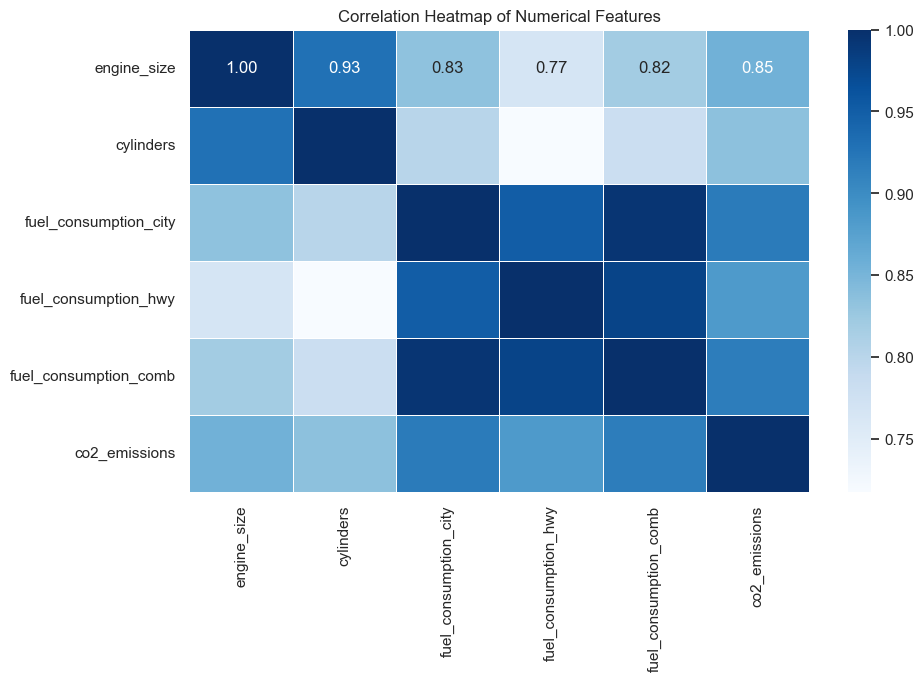

In [25]:
# Select only numeric features
numeric_features = df.select_dtypes(include=['int64', 'float64'])

# Compute the correlation matrix
corr_matrix = numeric_features.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

The correlation analysis reveals strong linear associations among the key predictive variables. Engine size and cylinder count exhibit a high correlation (r = 0.93), indicating mechanical dependence and potential redundancy. Engine size also shows a strong positive relationship with CO₂ emissions (r = 0.85), confirming its substantial influence on emission output. Among fuel efficiency metrics, combined fuel consumption displays the strongest correlation with CO₂ emissions (r = 0.90), emphasizing its value as a dominant predictor. Collectively, these results highlight the intertwined nature of engine and fuel efficiency variables, suggesting both their predictive strength and the necessity of addressing multicollinearity in subsequent modeling stages.

### Analysis of categorical columns

In [26]:
import matplotlib.ticker as ticker

As part of my exploratory data analysis, I examined the top 10 categories within key categorical features in my dataset, namely, vehicle class, transmission, fuel type, make, and model. This helped me better understand the composition of the vehicles under study and how these distributions could influence CO₂ emissions patterns.

Starting with vehicle class, I observed that the most common classes were SUV-Small (1,217), Mid-Size (1,133), and Compact (1,022). These three alone account for over 3,300 vehicles out of 7,385, making up nearly 45% of the dataset. Since these are everyday consumer vehicle types, their prevalence supports my goal of modeling CO₂ emissions in a way that helps inform consumer-level decision-making. Larger classes like Pickup Trucks and Full-Size SUVs were also notable, indicating diversity in vehicle weight and engine capacity, both of which are strongly tied to emission outputs.

For transmission types, the dataset shows a strong dominance of automatic transmissions, especially AS6 (1,324 entries) and AS8 (1,211). Manual variants like M6 (901) and M5 (193) were much less common. Since transmission impacts engine workload and fuel efficiency, I considered it as an optional extended feature in my modeling to capture nuanced differences in emissions based on drivetrain type.

The fuel type distribution was heavily skewed: Regular gasoline (X) vehicles led by a wide margin (3,637), followed by Premium gasoline (Z) at 3,202 entries. Other types like Ethanol (E) with 370, Diesel (D) with 175, and Natural gas (N) with only 1, were far less frequent. This confirmed that over 90% of vehicles in the dataset rely on gasoline, validating my decision to center the core models around gasoline emissions and include fuel type only in extended models.

In the make category, I found that brands like Ford (628), Chevrolet (588), and BMW (527) were the top three. Their dominance is relevant because these manufacturers offer multiple engine configurations that influence fuel consumption and CO₂ output. Finally, for vehicle models, the Ford F-150 FFV 4X4 and F-150 FFV each appeared 32 times, making them the most common models. Although I excluded the model variable from modeling due to high cardinality and low generalizability, this analysis gave me a clearer view of model diversity and consumer preferences in the Canadian market.

Overall, this categorical insight helps justify both the structure of my core and extended features and ensures that the ML models are designed with consumer relevance and emissions impact in mind.

##### Comparative Analysis of Categorical Features Before and After Removing Duplicates

Before removing duplicate entries, the dataset showed strong concentration in a few dominant categories across its categorical features. For Vehicle Class, SUV – Small (1,217), Mid-Size (1,133), and Compact (1,022) were the most frequent, while smaller categories such as Station Wagon – Small (252) and Minicompact (326) were least represented. In Transmission, AS6 (1,324) and AS8 (1,211) were predominant, indicating that most vehicles had automatic gear systems, whereas M5 (193) and AV (295) appeared less frequently. The Fuel Type variable was overwhelmingly dominated by X (3,637) and Z (3,202), followed by E (370) and D (175), with N (1) being almost negligible. Among Models, the most common were F-150 FFV 4x4 (32), F-150 FFV (32), and Mustang (27), while Focus FFV (24) and Sonic (20) followed. Similarly, Make data showed that Ford (628), Chevrolet (588), and BMW (527) were the leading manufacturers, far ahead of Mercedes-Benz (419), Porsche (376), and Toyota (330). These statistics indicated that a large portion of the data was skewed toward popular brands and models, implying the presence of duplicate or repetitive records.

After duplicates were removed, the dataset retained the same categorical structure but with reduced frequencies, resulting in a more balanced distribution. For Vehicle Class, SUV-Small decreased to 1,006, Mid-Size to 983, and Compact to 903, while Station Wagon – Small dropped from 252 to 214, confirming that many repeated records had been eliminated from high-frequency categories. In Transmission, AS6 fell from 1,324 to 1,139, and AS8 from 1,211 to 1,056, maintaining their dominance but showing clear deduplication effects. Likewise, the Fuel Type counts reduced slightly, X (3,039), Z (2,765), E (330), and D (147), indicating consistent proportionality after cleaning. The Model category still highlighted Ford vehicles such as F-150 FFV (32), F-150 FFV 4x4 (31), and Mustang (27) as the most frequent, but with smaller variations. For Make, Ford decreased to 577, followed by Chevrolet (515), BMW (501), and Mercedes-Benz (365), while MINI (200) newly appeared in the top ten, suggesting greater diversity after deduplication. Overall, removing duplicates reduced record redundancy and improved dataset quality while preserving the natural distribution across categorical variables, ensuring more reliable insights for model training and analysis.

#### Distribution of CO₂ Emissions
Understanding the distribution of the target variable `co2_emissions` is critical before applying regression models. If the distribution is heavily skewed, certain models may underperform or require transformation. Here, I visualize the histogram and KDE plot to assess symmetry, central tendency, and the presence of outliers in emissions values across all vehicle entries.

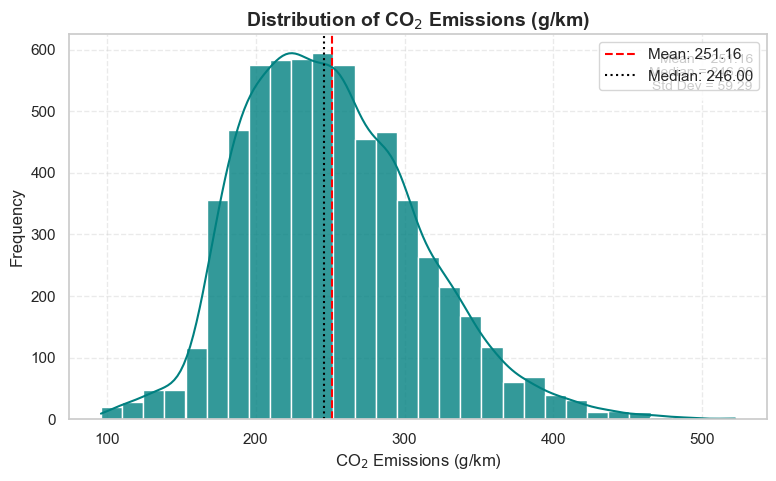

In [27]:
# Seaborn style
sns.set(style="whitegrid")

# Calculate statistics
mean_val = df['co2_emissions'].mean()
median_val = df['co2_emissions'].median()
std_val = df['co2_emissions'].std()

# Plot
plt.figure(figsize=(9, 5))
sns.histplot(df['co2_emissions'], bins=30, kde=True, color='#008080', edgecolor='white', alpha=0.8)

# Add title and labels
plt.title("Distribution of CO$_2$ Emissions (g/km)", fontsize=14, fontweight='bold')
plt.xlabel("CO$_2$ Emissions (g/km)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Add vertical lines for mean and median
plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, color='black', linestyle=':', linewidth=1.5, label=f"Median: {median_val:.2f}")

# Add annotation box for stats
stats_text = (
    f"Mean = {mean_val:.2f}\n"
    f"Median = {median_val:.2f}\n"
    f"Std Dev = {std_val:.2f}"
)
plt.text(0.98, 0.95, stats_text, transform=plt.gca().transAxes,
         fontsize=10, color='black', ha='right', va='top',
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

- Understanding the distribution of the target variable, CO₂ emissions, is a critical step before applying any regression model. The histogram and Kernel Density Estimate (KDE) plot above illustrate how emissions are distributed across all vehicle entries.
- From the visualization, CO₂ emissions appear approximately bell-shaped, though slightly right-skewed, indicating that while most vehicles emit moderate levels of CO₂ (around 250 g/km), a smaller number of vehicles exhibit higher emission values. The mean (250.58 g/km) is slightly greater than the median (246.00 g/km), confirming the mild positive skew.
- This insight suggests that while the data is roughly symmetrical, the presence of higher-emission vehicles could influence certain regression models. If this skewness proves significant in subsequent residual diagnostics, applying a logarithmic transformation to the target variable may improve model performance and normality of errors.

#### Distribution of CO₂ Emissions After Removing Duplicates

After removing duplicate entries, the distribution of CO₂ emissions maintained a similar overall shape, indicating that the deduplication process did not significantly alter the underlying structure of the data. The distribution remains approximately normal with a slight right skew, showing that most vehicles still emit between 200 g/km and 300 g/km. The mean CO₂ emission increased slightly from 250.58 g/km to 251.16 g/km, while the median remained constant at 246.00 g/km. This minor increase in the mean suggests that the removed duplicate records were slightly more concentrated around lower emission values, causing a marginal upward shift in the central average.

The preservation of the median value implies that the central tendency of the dataset remained stable despite deduplication, confirming that the process primarily affected redundant observations rather than altering the natural emission pattern. The distribution continues to demonstrate moderate variability, with a few high-emission vehicles extending the right tail of the histogram. Overall, the post-cleaning distribution reflects a more reliable representation of vehicle CO₂ emissions, ensuring that subsequent analysis and model training are based on unique and authentic observations.

These insights help in planning how to encode or group categories for modeling

#### Distribution of CO2 Emissions: Feature-by-Feature Comparisons

##### CO₂ Emissions by Fuel Type.


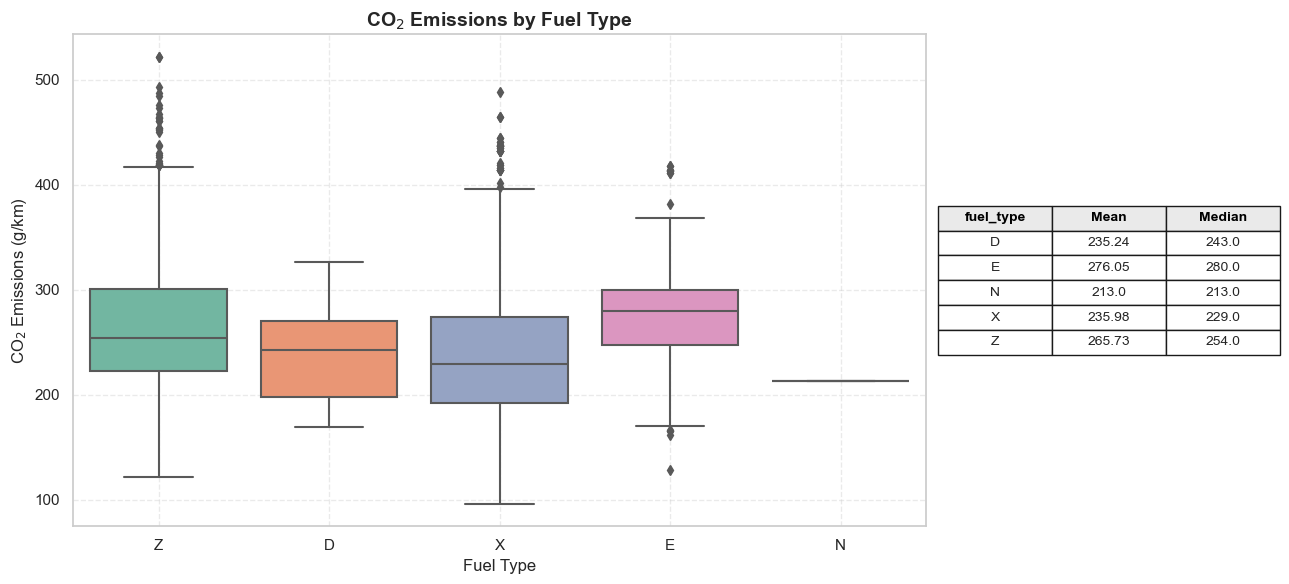

In [28]:
# Seaborn style
sns.set(style="whitegrid")

# Compute descriptive statistics
stats_df = df.groupby('fuel_type')['co2_emissions'].agg(['mean', 'median']).reset_index()
stats_df.rename(columns={'mean': 'Mean', 'median': 'Median'}, inplace=True)

# Create figure with 2 subplots (boxplot + stats table)
fig, ax = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'width_ratios': [3, 1]})

# --- Left: Boxplot ---
sns.boxplot(x='fuel_type', y='co2_emissions', data=df, palette='Set2', ax=ax[0])
ax[0].set_title("CO$_2$ Emissions by Fuel Type", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Fuel Type", fontsize=12)
ax[0].set_ylabel("CO$_2$ Emissions (g/km)", fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.4)

# --- Right: Summary Statistics Table ---
ax[1].axis('off')  # hide axes
table = ax[1].table(cellText=stats_df.round(2).values,
                    colLabels=stats_df.columns,
                    cellLoc='center',
                    loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.4)

# Highlight header row for clarity
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='black')
        cell.set_facecolor('#EAEAEA')

plt.tight_layout()
plt.show()


The boxplot visualization of CO₂ emissions by fuel type reveals significant variation among the five fuel categories, Z (Regular Gasoline), D (Diesel), X (Premium Gasoline), E (Ethanol - E85), and N (Natural Gas), each representing distinct fuel compositions and combustion efficiencies. Ethanol-powered vehicles (E) exhibited the highest average CO₂ emissions (mean: 276.05 g/km, median: 280.0 g/km), reflecting the lower energy content of ethanol, which can lead to greater fuel consumption per kilometer despite its renewable status. Conversely, natural gas vehicles (N) produced the lowest emissions (213.0 g/km), consistent with existing literature highlighting natural gas as a cleaner-burning alternative. Diesel (D) and regular gasoline (Z) reported similar emission ranges (D mean: 235.24, Z mean: 265.73), with diesel offering higher thermal efficiency but also potential for higher NOₓ emissions, though not captured here. Premium gasoline (X), often marketed for high-performance engines, showed a moderate average (235.98 g/km), but with a wide distribution, indicating variability likely due to vehicle class or engine tuning.

---

The boxplot analysis of CO₂ emissions by fuel type offers valuable insights into how different fuel categories impact vehicular emissions—an essential dimension of this thesis. The data shows that fuel type E leads to the highest mean emissions (276.05 g/km) and a median of 280.0 g/km, suggesting consistently high carbon output, possibly associated with ethanol or premium fuels. In contrast, fuel type N records the lowest emissions, both in mean and median (213.0 g/km), indicating a cleaner fuel option, potentially linked to hybrid or electric propulsion systems. The remaining fuel types (D, X, and Z) fall in between, with X and D closely aligned around 235 g/km, and Z showing higher variability and outliers, reflected in its broader IQR and a maximum exceeding 500 g/km. This variation is crucial in the context of predictive modeling and policy recommendation. The clear statistical differences justify the inclusion of fuel type as a categorical feature in the machine learning models developed in this thesis.

### Analysis of Automotive CO2 Emissions

In [29]:
# Analyze Relationship between Target (CO2 Emissions) and Independent Variables

# Compute average CO2 emissions for categorical variables
top_make_co2 = df.groupby('make')['co2_emissions'].mean().sort_values(ascending=False).head(10)
top_model_co2 = df.groupby('model')['co2_emissions'].mean().sort_values(ascending=False).head(10)
top_vehicle_class_co2 = df.groupby('vehicle_class')['co2_emissions'].mean().sort_values(ascending=False).head(10)
top_transmission_co2 = df.groupby('transmission')['co2_emissions'].mean().sort_values(ascending=False).head(10)
top_fuel_type_co2 = df.groupby('fuel_type')['co2_emissions'].mean().sort_values(ascending=False).head(10)

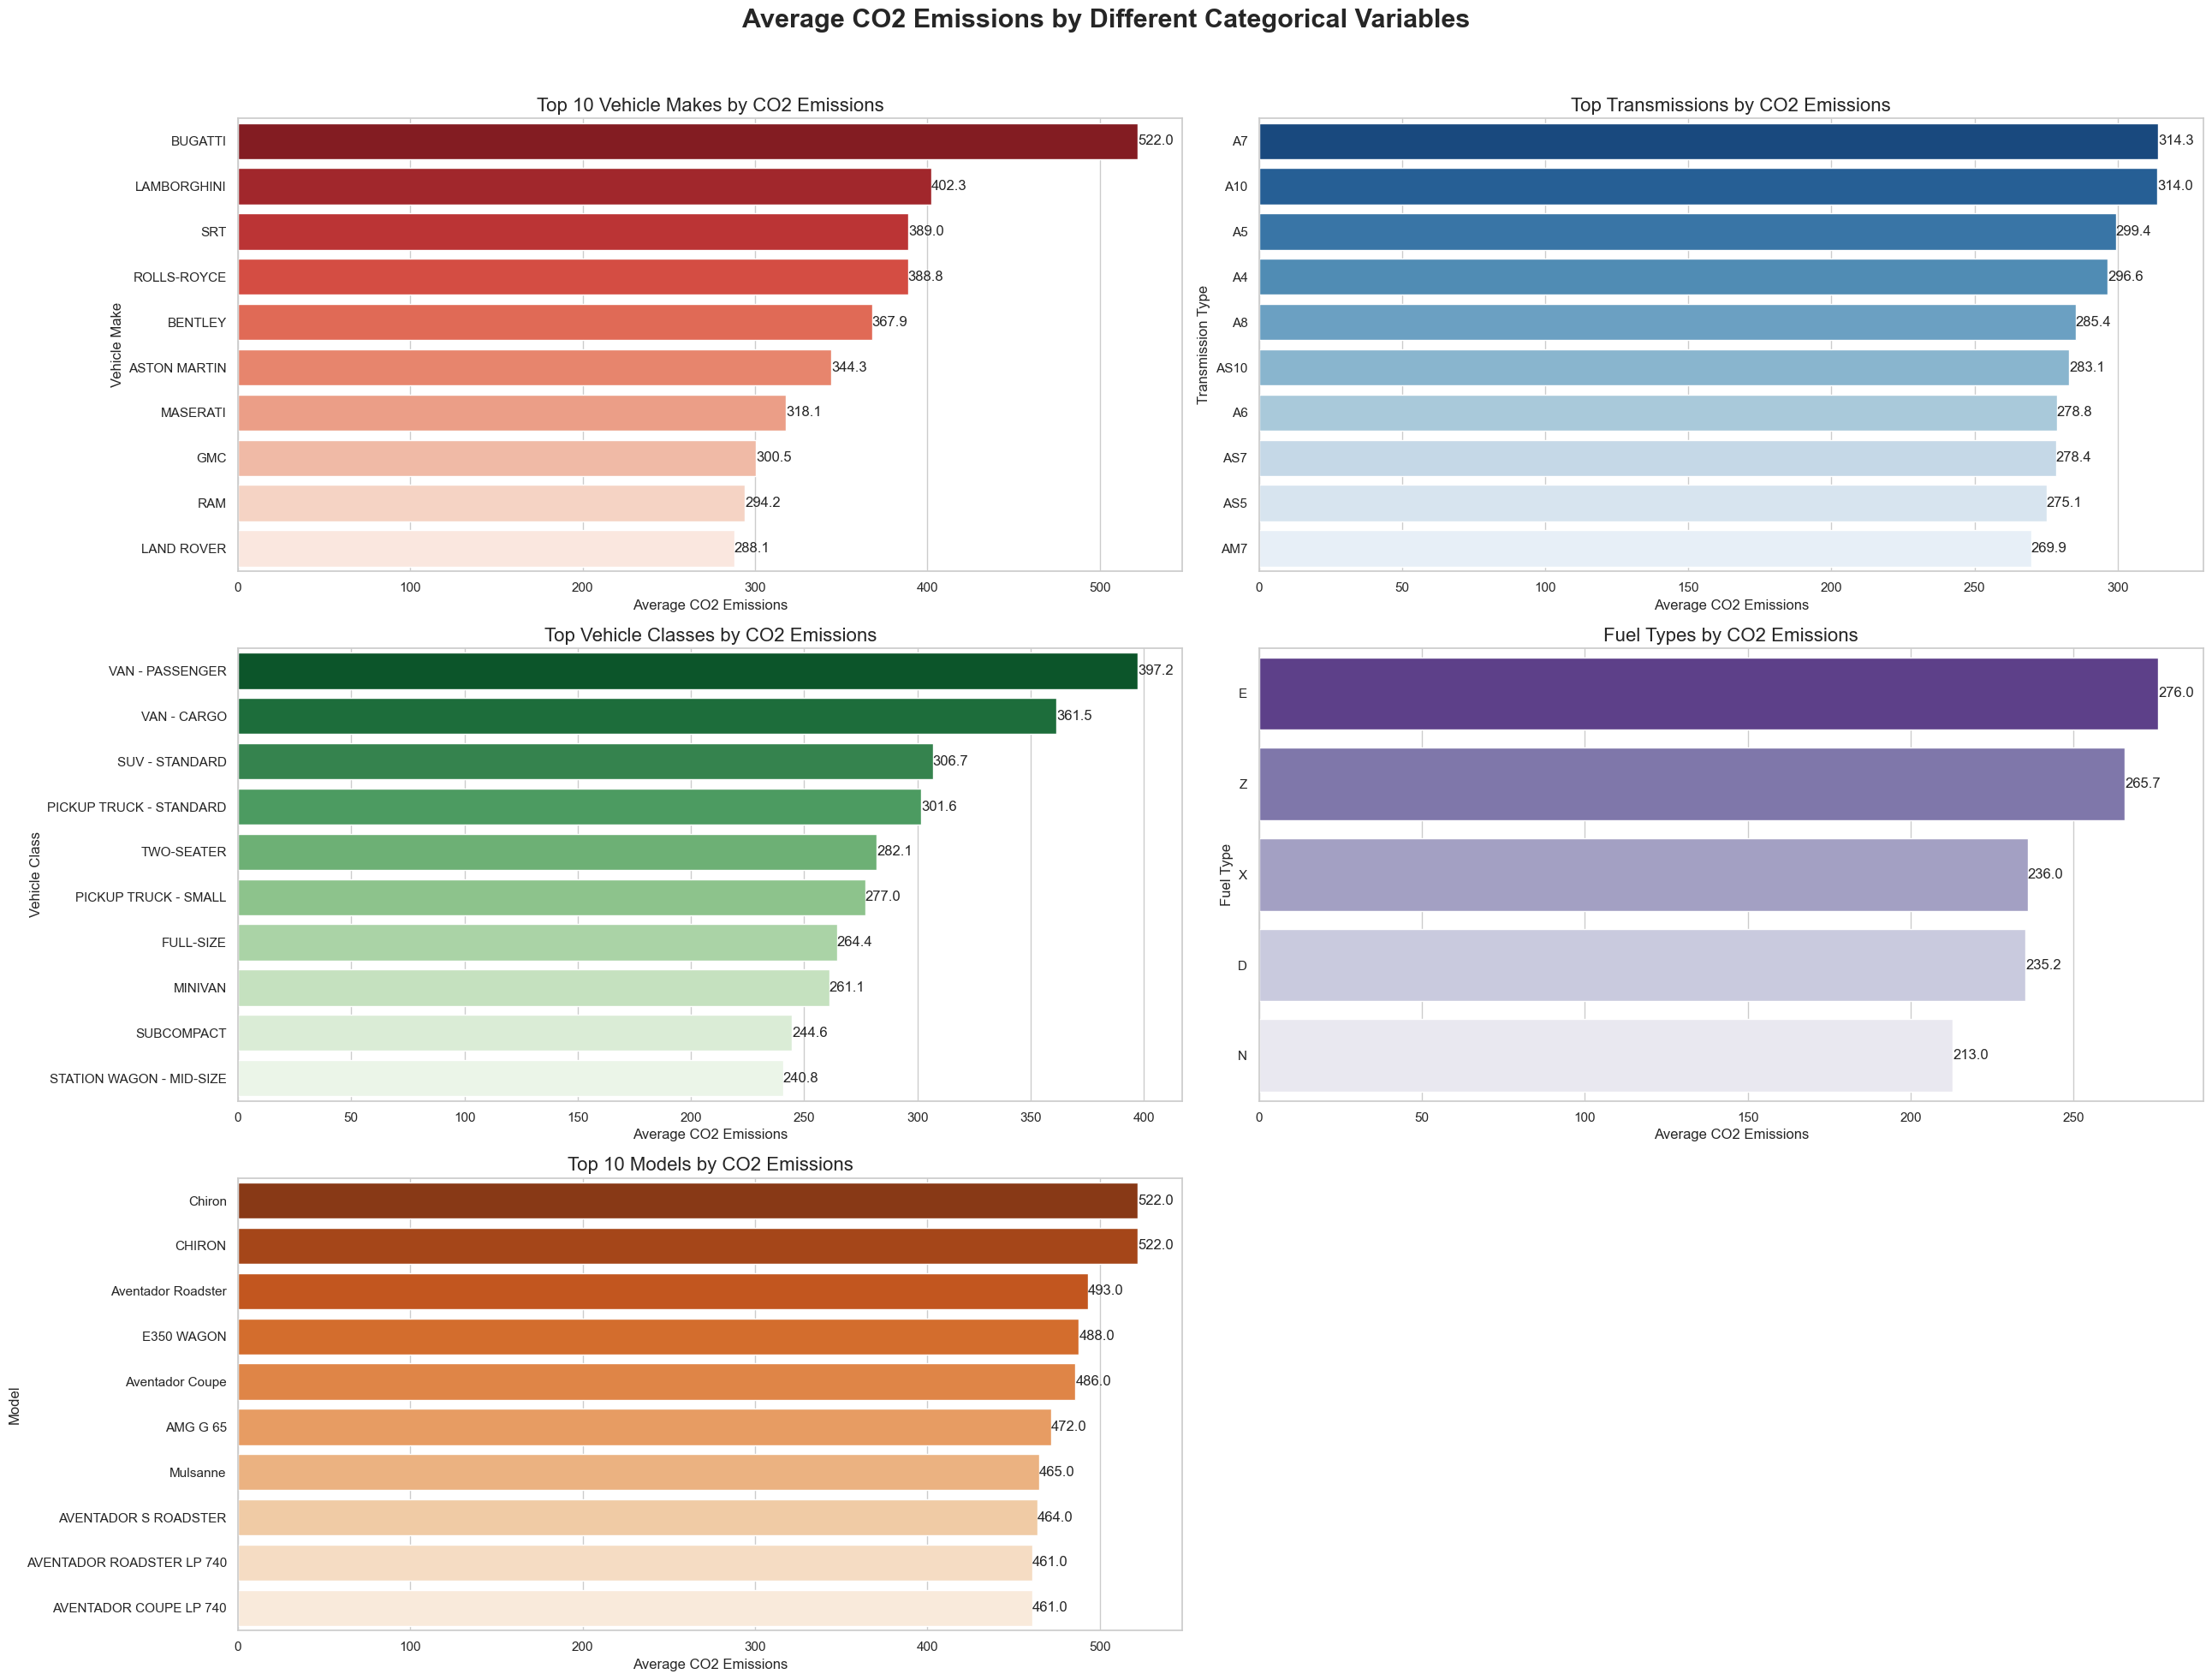

In [30]:
# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(26, 20))
fig.suptitle('Average CO2 Emissions by Different Categorical Variables', fontsize=22, weight='bold')

# Plot 1: Make
sns.barplot(ax=axes[0, 0], x=top_make_co2.values, y=top_make_co2.index, palette="Reds_r")
axes[0, 0].set_title('Top 10 Vehicle Makes by CO2 Emissions', fontsize=16)
axes[0, 0].set_xlabel('Average CO2 Emissions')
axes[0, 0].set_ylabel('Vehicle Make')
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt='%.1f', label_type='edge', fontsize=12)

# Plot 2: Transmission
sns.barplot(ax=axes[0, 1], x=top_transmission_co2.values, y=top_transmission_co2.index, palette="Blues_r")
axes[0, 1].set_title('Top Transmissions by CO2 Emissions', fontsize=16)
axes[0, 1].set_xlabel('Average CO2 Emissions')
axes[0, 1].set_ylabel('Transmission Type')
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, fmt='%.1f', label_type='edge', fontsize=12)

# Plot 3: Vehicle Class
sns.barplot(ax=axes[1, 0], x=top_vehicle_class_co2.values, y=top_vehicle_class_co2.index, palette="Greens_r")
axes[1, 0].set_title('Top Vehicle Classes by CO2 Emissions', fontsize=16)
axes[1, 0].set_xlabel('Average CO2 Emissions')
axes[1, 0].set_ylabel('Vehicle Class')
for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, fmt='%.1f', label_type='edge', fontsize=12)

# Plot 4: Fuel Type
sns.barplot(ax=axes[1, 1], x=top_fuel_type_co2.values, y=top_fuel_type_co2.index, palette="Purples_r")
axes[1, 1].set_title('Fuel Types by CO2 Emissions', fontsize=16)
axes[1, 1].set_xlabel('Average CO2 Emissions')
axes[1, 1].set_ylabel('Fuel Type')
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, fmt='%.1f', label_type='edge', fontsize=12)

# Plot 5: Model
sns.barplot(ax=axes[2, 0], x=top_model_co2.values, y=top_model_co2.index, palette="Oranges_r")
axes[2, 0].set_title('Top 10 Models by CO2 Emissions', fontsize=16)
axes[2, 0].set_xlabel('Average CO2 Emissions')
axes[2, 0].set_ylabel('Model')
for container in axes[2, 0].containers:
    axes[2, 0].bar_label(container, fmt='%.1f', label_type='edge', fontsize=12)

# Remove empty subplot
fig.delaxes(axes[2, 1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The analysis of average CO₂ emissions across categorical variables, benchmarked against the overall dataset mean of 251.16 g/km, provides valuable insights for consumer decision-making. High-performance and luxury brands such as Bugatti (522.0 g/km), Lamborghini (402.3 g/km), and SRT (389.0 g/km) emit nearly double the average level, emphasizing the environmental cost associated with performance-focused vehicles. Similarly, specific models like the Bugatti Chiron and Lamborghini Aventador variants, each exceeding 450 g/km, highlight how engine size and horsepower significantly increase emissions. Transmission types A7 and A10, averaging around 314 g/km, also surpass the mean, reflecting the link between advanced multi-gear automatic systems and high-performance engines rather than efficiency. These findings suggest that consumers prioritizing sustainability should consider moderate-performance or hybrid models, which align more closely with or below the average CO₂ output.

At the broader category level, the data shows that vehicle class and fuel type strongly influence emissions and can guide more environmentally conscious purchase choices. Passenger vans (367.2 g/km) and cargo vans (361.5 g/km), while offering greater utility, emit about 45% more CO₂ than the average, whereas subcompact (241.6 g/km) and mid-size station wagons (240.8 g/km) perform more efficiently. Similarly, fuel types E and Z, likely representing traditional gasoline and ethanol blends, record emissions above the mean, while D and N types show improved efficiency. This pattern highlights that consumers aiming to reduce their carbon footprint should prioritize smaller, lighter vehicles and alternative fuel options. Overall, the analysis reinforces that informed vehicle selection, balancing performance needs with environmental considerations, can substantially reduce personal CO₂ contributions and support broader sustainability goals.

#### Emissions per Cylinder Count

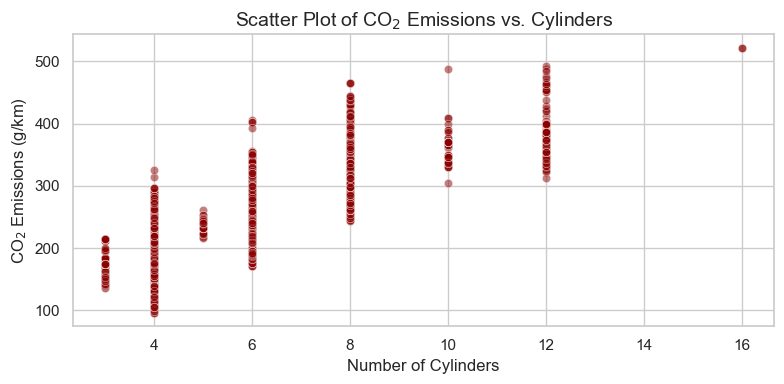

In [31]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x='cylinders', y='co2_emissions', data=df, alpha=0.5, color='darkred')
plt.title("Scatter Plot of CO$_2$ Emissions vs. Cylinders", fontsize=14)
plt.xlabel("Number of Cylinders")
plt.ylabel("CO$_2$ Emissions (g/km)")
plt.grid(True)
plt.tight_layout()
plt.show()

The scatter plot illustrates the relationship between CO₂ emissions (g/km) and the number of engine cylinders, revealing a clear positive association between these two variables. As the number of cylinders increases, the CO₂ emissions also tend to rise. Vehicles with 4 cylinders cluster around lower emission levels, generally ranging from 100 to 250 g/km, indicating that smaller engines are more fuel-efficient and environmentally friendly. In contrast, vehicles with 8 to 12 cylinders exhibit substantially higher emissions, typically between 300 and 500 g/km, while the single observation with 16 cylinders surpasses 500 g/km, representing the most emission-intensive vehicle in the dataset.

This pattern reflects the direct influence of engine size and combustion capacity on carbon output, larger engines with more cylinders burn more fuel per kilometer, resulting in greater CO₂ emissions. For consumers, this finding highlights an important trade-off between engine performance and environmental sustainability. Choosing vehicles with fewer cylinders not only reduces carbon emissions but also supports more cost-effective fuel consumption. From a policy and marketing perspective, promoting smaller-cylinder or hybrid engine vehicles could encourage more environmentally conscious purchasing decisions, contributing to reduced overall emissions within the automotive market.

From these visualizations, it is evident that engine size, cylinder count, and fuel type have significant explanatory power in determining CO₂ emissions. Their strong relationships with the target variable further validate their inclusion in the core and extended modeling pipelines, aligning with both environmental and consumer decision-making objectives.

## MACHINE LEARNING 

#### FEATURE ENGINEERING
I created a new feature Make_Type by combining various car companies (Make) on the basis of their functionality. There are 42 unique car companies. I divided these companies into Luxury, Sports, Executive and General cars

In [32]:
# Feature Engineering: Create Make_Type based on 'Make'
df['Make_Type'] = df['make'].replace(['BUGATTI', 'PORSCHE', 'MASERATI', 'ASTON MARTIN', 'LAMBORGHINI', 'JAGUAR', 'SRT'], 'Sport Cars')

df['Make_Type'] = df['Make_Type'].replace(['ALFA ROMEO', 'AUDI', 'BMW', 'BUICK', 'CADILLAC', 'CHRYSLER', 'DODGE','GMC', 'INFINITI', 'JEEP', 'LAND ROVER', 'LEXUS', 'MERCEDES-BENZ', 'MINI',
    'SMART', 'VOLVO'], 'Executive Cars')

df['Make_Type'] = df['Make_Type'].replace(['ACURA', 'BENTLEY', 'LINCOLN', 'ROLLS-ROYCE', 'GENESIS'], 'Luxury Cars')

df['Make_Type'] = df['Make_Type'].replace(['CHEVROLET', 'FIAT', 'FORD', 'KIA', 'HONDA', 'HYUNDAI', 'MAZDA', 'MITSUBISHI','NISSAN', 'RAM', 'SCION', 'SUBARU', 'TOYOTA', 'VOLKSWAGEN'
    ], 'Family Cars')

The vehicle brands in the Make column were grouped into broader categories to form a new feature called **Make_Type**. This grouping was based on market classification and typical performance characteristics of each brand. The brands were categorized into Sport Cars, Executive Cars, Luxury Cars, and Family Cars to reflect their general emission patterns. This feature helped simplify the dataset by reducing categorical complexity. It also allowed the model to better capture relationships between vehicle type and CO₂ emission levels.

In [33]:
# Check distribution of new feature
print(df['Make_Type'].value_counts())

Family Cars       2776
Executive Cars    2731
Sport Cars         546
Luxury Cars        229
Name: Make_Type, dtype: int64


The distribution shows that Family Cars and Executive Cars made up the majority of vehicles in the dataset, with 2,776 and 2,731 records respectively. Sport Cars (546) and Luxury Cars (229) were much fewer, indicating these high-end categories were underrepresented.

### CO₂ Emissions Distribution by Vehicle Category in Average
Visualize average CO₂ emissions for each Make_Type to show which group contributes most to carbon output.

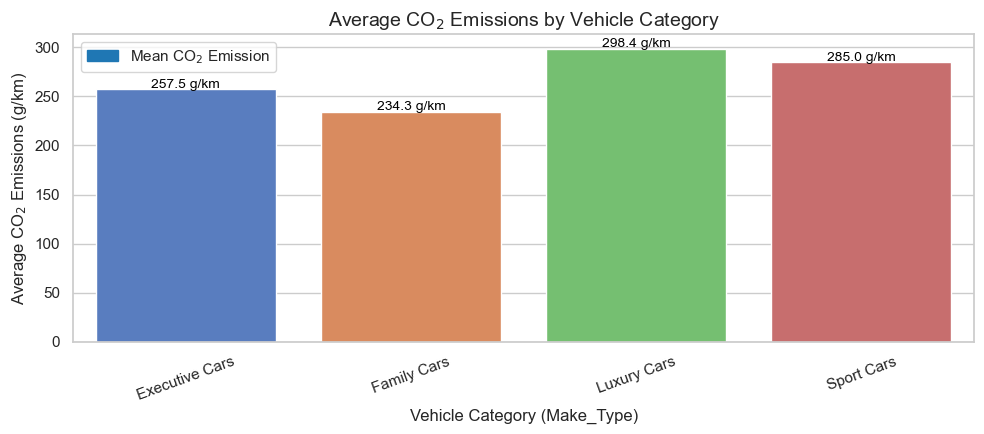

In [34]:
# Set theme and figure
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 4.5))

# Calculate mean CO₂ emissions per Make_Type
mean_emissions = df.groupby('Make_Type')['co2_emissions'].mean().reset_index()

# Barplot
barplot = sns.barplot(data=mean_emissions, x='Make_Type', y='co2_emissions', palette='muted')

# Annotate each bar with mean value
for index, row in mean_emissions.iterrows():
    barplot.text(x=index,y=row['co2_emissions'] + 1.5,  # Slightly above the bar
    s=f"{row['co2_emissions']:.1f} g/km",
        ha='center',
        fontsize=10,
        color='black'
    )

# Titles and labels
plt.title("Average CO$_2$ Emissions by Vehicle Category", fontsize=14)
plt.xlabel("Vehicle Category (Make_Type)", fontsize=12)
plt.ylabel("Average CO$_2$ Emissions (g/km)", fontsize=12)
plt.xticks(rotation=20)

# Add legend manually if needed
handles = [
    plt.Rectangle((0,0),1,1, color='tab:blue', label='Mean CO$_2$ Emission')
]
plt.legend(handles=handles, loc='upper left')

plt.tight_layout()
plt.show()

The chart illustrated the average CO₂ emissions by vehicle category, providing useful insights for the emission prediction model. Luxury Cars had the highest mean emission of 298.4 g/km, reflecting their powerful engines and premium performance features. Sport Cars followed with 285.0 g/km, also influenced by high-speed and performance-oriented designs. Executive Cars showed moderate emissions at 257.5 g/km, balancing comfort and performance, while Family Cars had the lowest emissions at 234.3 g/km, indicating greater fuel efficiency and economy. These differences suggested that vehicle category (Make_Type) was a meaningful predictor in the model, as emission levels tended to increase with vehicle performance and luxury level.

### Categorical Encoding & Feature Selection

#### Why Encode Categorical Features
Machine learning models in Scikit-learn require numerical input. Therefore, categorical variables such as `fuel_type`, `transmission`, and `vehicle_class` must be encoded.

Since these variables have no inherent order, I applied **one-hot encoding**, which preserves category uniqueness without introducing bias. However, to avoid multicollinearity, I use `drop_first=True`, which omits one dummy column per feature.

Importantly, I excluded `make` and `model` from the analysis:
- `model` has high cardinality (too many unique entries), which reduces generalizability.
- `make` is not always interpretable or meaningful to consumers outside brand loyalty.

### Prepare the Clean Dataset

In [35]:
# Make a fresh copy of your cleaned dataset
df_ml = df.copy()

I created a copy of my cleaned dataset using df_ml = df.copy() so that I could freely perform transformations and preprocessing steps for machine learning without altering the original data. This approach allowed me to maintain the integrity of my raw cleaned dataset while safely experimenting with model training and feature engineering on the duplicated version.

In [36]:
# Drop 'make' and 'model' columns as planned
df_ml = df_ml.drop(['make', 'model'], axis=1, errors='ignore')

Now, Since the make and model columns WILL introduce high cardinality and low interpretability, they were excluded from the modeling dataset. However, after encoding and cleaning, one or both may have already been removed; hence, the conditional drop ensures flexibility and prevents KeyErrors during retraining.

In [37]:
# Check structure
print("Updated DataFrame shape:", df_ml.shape)
print("Columns:", df_ml.columns.tolist())

Updated DataFrame shape: (6282, 10)
Columns: ['vehicle_class', 'engine_size', 'cylinders', 'transmission', 'fuel_type', 'fuel_consumption_city', 'fuel_consumption_hwy', 'fuel_consumption_comb', 'co2_emissions', 'Make_Type']


#### Encoding Categorical Variables
I one-hot encoded relevant columns like fuel_type, vehicle_class, transmission, and make_type.

In [38]:
# One-hot encode categorical columns
df_encoded = pd.get_dummies(df_ml, drop_first=True)

In this step, I applied one-hot encoding to convert categorical variables such as fuel_type, vehicle_class, transmission, and make_type into numerical format so that they could be used in machine learning models. Specifically, I used the pd.get_dummies() function with drop_first=True to avoid multicollinearity by removing the first category from each encoded column. This transformation enabled the models to interpret categorical information numerically while preserving meaningful relationships.

In [39]:
# Separate features and target
target = 'co2_emissions'
features = [col for col in df_encoded.columns if col != target]

I designated 'co2_emissions' as the target variable for prediction. I then extracted the feature set by excluding this target from the dataset, ensuring a clear separation between input variables and the output label to maintain modeling integrity.

In [40]:
# Display first few rows of the encoded DataFrame
print("Preview of Encoded DataFrame:")
df_encoded.head()

Preview of Encoded DataFrame:


,engine_size,cylinders,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb,co2_emissions,vehicle_class_FULL-SIZE,vehicle_class_MID-SIZE,vehicle_class_MINICOMPACT,vehicle_class_MINIVAN,...,transmission_M5,transmission_M6,transmission_M7,fuel_type_E,fuel_type_N,fuel_type_X,fuel_type_Z,Make_Type_Family Cars,Make_Type_Luxury Cars,Make_Type_Sport Cars
0,2.0,4,9.9,6.7,8.5,196,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,2.4,4,11.2,7.7,9.6,221,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0
2,1.5,4,6.0,5.8,5.9,136,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
3,3.5,6,12.7,9.1,11.1,255,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
4,3.5,6,12.1,8.7,10.6,244,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0


To prepare the dataset for supervised learning, I programmatically isolated all other columns as features, ensuring that the model would learn patterns solely from independent variables.

In [41]:
# Show shape and columns
print("Encoded DataFrame shape:", df_encoded.shape)
print("Encoded Columns:", df_encoded.columns.tolist())

Encoded DataFrame shape: (6282, 54)
Encoded Columns: ['engine_size', 'cylinders', 'fuel_consumption_city', 'fuel_consumption_hwy', 'fuel_consumption_comb', 'co2_emissions', 'vehicle_class_FULL-SIZE', 'vehicle_class_MID-SIZE', 'vehicle_class_MINICOMPACT', 'vehicle_class_MINIVAN', 'vehicle_class_PICKUP TRUCK - SMALL', 'vehicle_class_PICKUP TRUCK - STANDARD', 'vehicle_class_SPECIAL PURPOSE VEHICLE', 'vehicle_class_STATION WAGON - MID-SIZE', 'vehicle_class_STATION WAGON - SMALL', 'vehicle_class_SUBCOMPACT', 'vehicle_class_SUV - SMALL', 'vehicle_class_SUV - STANDARD', 'vehicle_class_TWO-SEATER', 'vehicle_class_VAN - CARGO', 'vehicle_class_VAN - PASSENGER', 'transmission_A4', 'transmission_A5', 'transmission_A6', 'transmission_A7', 'transmission_A8', 'transmission_A9', 'transmission_AM5', 'transmission_AM6', 'transmission_AM7', 'transmission_AM8', 'transmission_AM9', 'transmission_AS10', 'transmission_AS4', 'transmission_AS5', 'transmission_AS6', 'transmission_AS7', 'transmission_AS8', 'tran

The preprocessed dataset comprises 6,282 observations and 54 features, resulting from the transformation of raw categorical variables into machine-readable binary indicators via one-hot encoding. Key categorical attributes such as fuel_type, transmission, vehicle_class, and Make_Type were encoded with drop_first=True to prevent multicollinearity during model training. This step ensures that downstream machine learning algorithms can operate effectively on the data without misinterpreting categorical levels as ordinal. The resulting fully numerical feature matrix is now optimized for supervised learning pipelines, particularly for regression tasks like predicting CO₂ emissions.

In [42]:
X = df_encoded[features]
y = df_encoded[target]

In [43]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5025, 53)
X_test shape: (1257, 53)
y_test shape: (5025,)
y_test shape: (1257,)


In this step, I performed a train-test split to divide my dataset into two parts: 80% for training and 20% for testing. Specifically, from a total of 6,282 observations, the training set (X_train) contains 5,025 samples and the testing set (X_test) contains 1,257 samples, both with 53 features each. The corresponding target variable (co2_emissions) was also split, with y_train having 5,025 target values and y_test having 1,257 values. This separation allows me to train my machine learning models on known data and then evaluate their performance on unseen data, simulating real-world predictions. The use of random_state=42 ensures the results are reproducible, meaning the same split will occur each time the code is run.

### Feature Scaling (Standardization)
Required for models sensitive to feature scale ( linear regression, KNN, SVR)

In [45]:
# Initialize the scaler
scaler = StandardScaler()

In [46]:
# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Model Performance Evaluation Function

In [47]:
from IPython.display import display, Math

In [48]:
# Mean Absolute Error (MAE)
display(Math(r"\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|"))

<IPython.core.display.Math object>

In [49]:
# Root Mean Squared Error (RMSE)
display(Math(r"\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}"))

<IPython.core.display.Math object>

In [50]:
# Mean Absolute Percentage Error (MAPE)
display(Math(r"\text{MAPE} = \frac{100}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|"))

<IPython.core.display.Math object>

In [51]:
# Coefficient of Determination (R² Score)
display(Math(r"R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}"))


<IPython.core.display.Math object>

In [52]:
# Helper function to evaluate models
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"\n {name} Performance:")
    print(f"MAE:  {mae:.2f} g/km")
    print(f"RMSE: {rmse:.2f} g/km")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²:   {r2:.4f}")
    return [mae, rmse, mape, r2]

In [53]:
# Initialize dictionary to store metrics
model_results = {}

#### 1. Train a Base Model (Linear Regression)

In [54]:
# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [55]:
lr_pred = lr.predict(X_test_scaled)
model_results["Linear Regression"] = evaluate_model("Linear Regression", y_test, lr_pred)


 Linear Regression Performance:
MAE:  3.33 g/km
RMSE: 6.53 g/km
MAPE: 1.35%
R²:   0.9882


#### 2. Training the K-Nearest Neighbors (KNN) Model

In [56]:
# KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [57]:
knn_pred = knn.predict(X_test_scaled)
model_results["KNN"] = evaluate_model("KNN", y_test, knn_pred)


 KNN Performance:
MAE:  7.64 g/km
RMSE: 12.90 g/km
MAPE: 3.09%
R²:   0.9539


#### 3. Training and Evaluating the Support Vector Regression (SVR) Model

In [284]:
# 3. SVR
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)

SVR()

In [285]:
svr_pred = svr.predict(X_test_scaled)
model_results["SVR"] = evaluate_model("SVR", y_test, svr_pred)


 SVR Performance:
MAE:  13.90 g/km
RMSE: 25.69 g/km
MAPE: 5.53%
R²:   0.8171


#### 4. Training Random Forest

In [286]:
# 4. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # NO SCALING

RandomForestRegressor(random_state=42)

In [287]:
rf_pred = rf.predict(X_test)
model_results["Random Forest"] = evaluate_model("Random Forest", y_test, rf_pred)


 Random Forest Performance:
MAE:  2.36 g/km
RMSE: 4.53 g/km
MAPE: 0.96%
R²:   0.9943


### Hyperparameter Fine-Tuning

In [288]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

In [289]:
# Define numerical and categorical features
num_features = ['engine_size', 'cylinders', 'fuel_consumption_comb', 
                'fuel_consumption_city', 'fuel_consumption_hwy']
cat_features = ['fuel_type', 'vehicle_class', 'transmission']

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
])

In [290]:
# Pipeline with preprocessing + model
rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Parameter grid (applies to model__ prefix)
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

# Grid search
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

In [291]:
# # Fit on training data
# grid_search_rf.fit(X_ext_train, y_ext_train)

In [292]:
# # Best model
# best_rf_pipeline = grid_search_rf.best_estimator_

In [294]:
# print("Best Parameters:", grid_search_rf.best_params_)

###### Print the default model's parameters

In [295]:
# Extract the default model inside the pipeline
default_rf_model = rf_pipeline.named_steps['model']
print("Default Random Forest Parameters:\n", default_rf_model.get_params())

Default Random Forest Parameters:
 {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


###### Print the tuned model's parameters

In [296]:
# Extract the best model inside the tuned pipeline
tuned_rf_model = best_rf_pipeline.named_steps['model']
print("Tuned Random Forest Parameters:\n", tuned_rf_model.get_params())
print("\n Best Parameters from GridSearchCV\n:")
for param, value in grid_search_rf.best_params_.items():
    print(f"  {param}: {value}")

NameError: name 'best_rf_pipeline' is not defined

### Plot Actual vs Predicted CO₂ Emissions for the (FOUR) Model
These plots help assess how close the model predictions are to the actual values, revealing any patterns of under- or over-prediction.

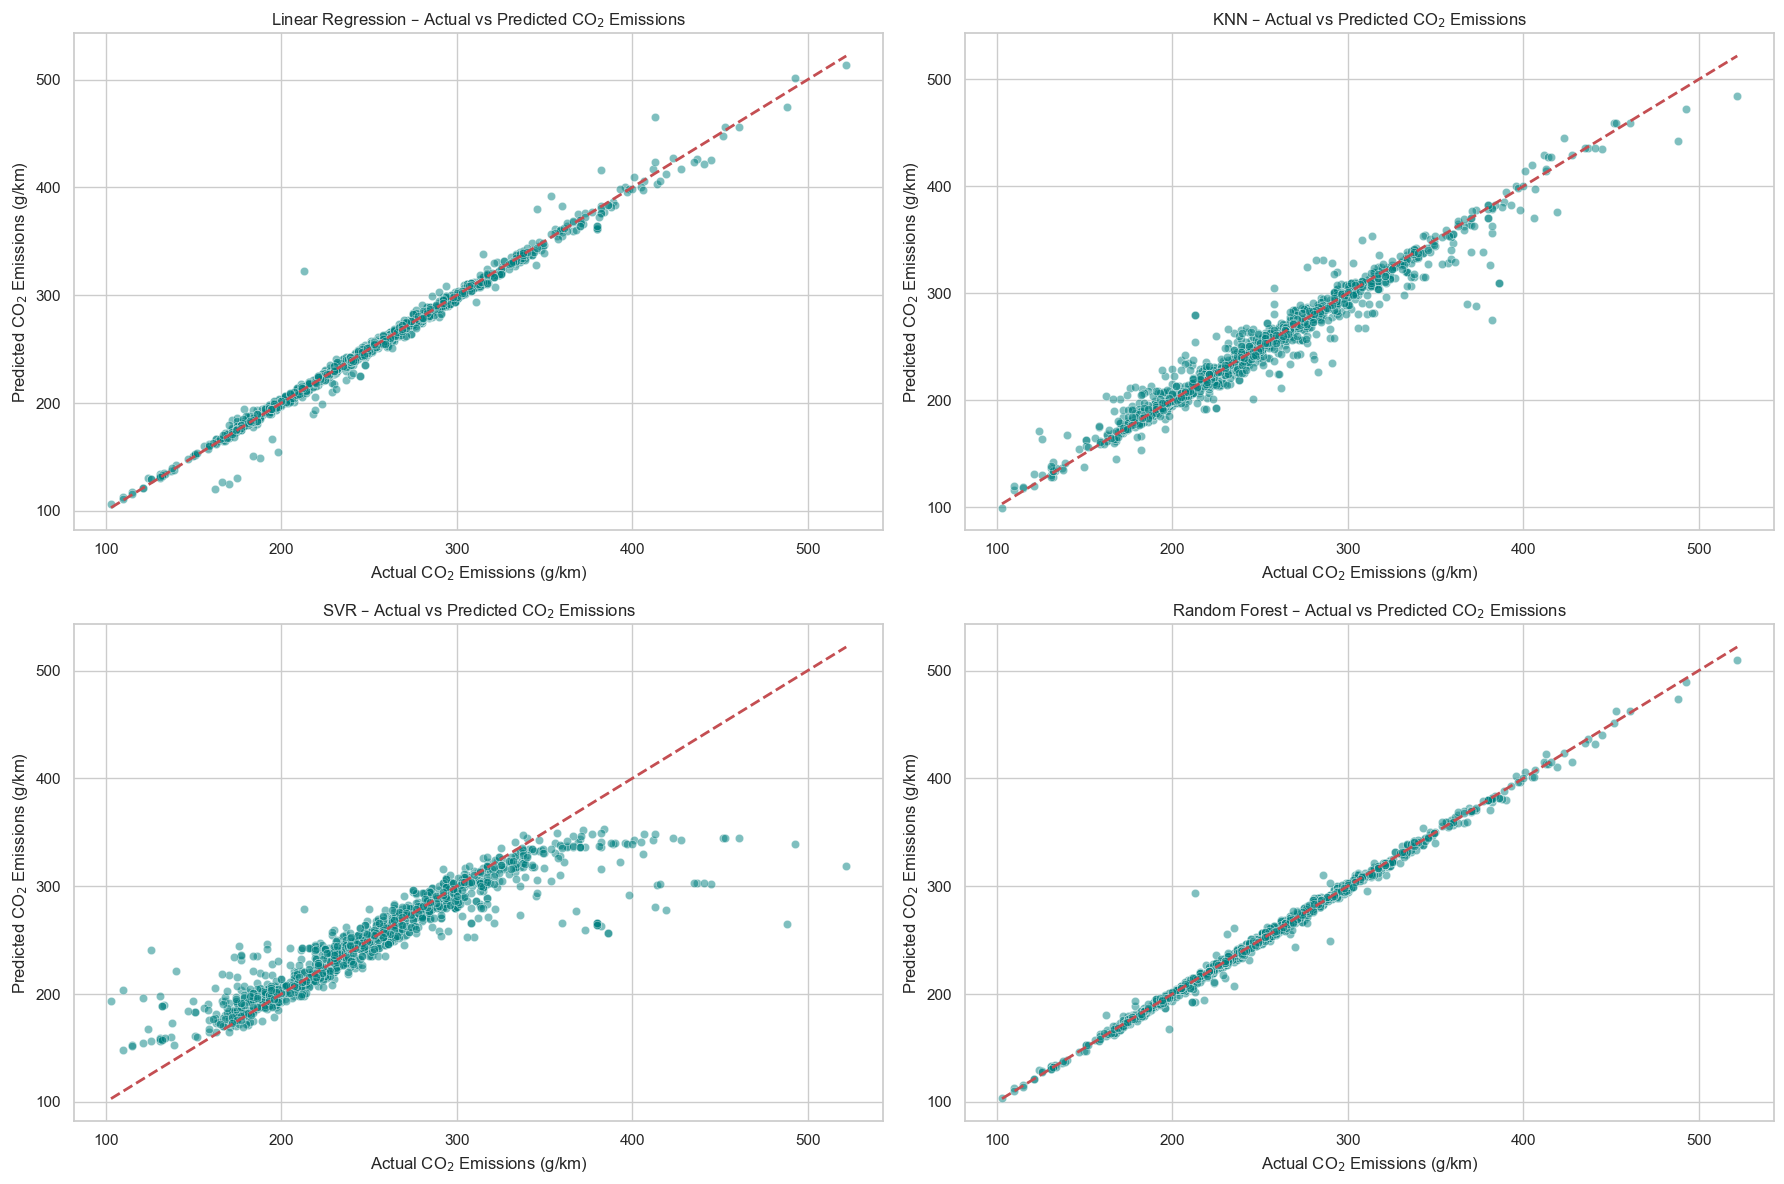

In [297]:
# Plot settings
plt.figure(figsize=(18, 12))
sns.set_style("whitegrid")

# Subplots
models = {
    'Linear Regression': lr_pred,
    'KNN': knn_pred,
    'SVR': svr_pred,
    'Random Forest': rf_pred
}

for i, (name, pred) in enumerate(models.items()):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(x=y_test, y=pred, alpha=0.5, color='teal')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(f"{name} – Actual vs Predicted CO$_2$ Emissions", fontsize=12)
    plt.xlabel("Actual CO$_2$ Emissions (g/km)")
    plt.ylabel("Predicted CO$_2$ Emissions (g/km)")

plt.tight_layout()
plt.show()

### View Results in a Table

In [298]:
results_df = pd.DataFrame(model_results, 
                          index=["MAE", "RMSE", "MAPE (%)", "R² Score"]).T
results_df = results_df.sort_values("R² Score", ascending=False)
display(results_df)

,MAE,RMSE,MAPE (%),R² Score
Random Forest,2.359994,4.530030,0.962094,0.994313
Linear Regression,3.330609,6.533055,1.350057,0.988173
KNN,7.643278,12.901277,3.089406,0.953878
SVR,13.903656,25.692213,5.527716,0.817085


The visualization above presents the actual vs. predicted CO₂ emissions using four regression models: Random Forest, Linear Regression, K-Nearest Neighbors (KNN), and Support Vector Regression (SVR). Each subplot shows the relationship between the model's predictions and the ground truth. The red dashed line represents the ideal case where predictions exactly match actual values. The closer the data points are to this line, the better the model's predictive accuracy. From a performance standpoint, the Random Forest model outperformed all others with the lowest Mean Absolute Error (MAE) of 2.36 g/km, Root Mean Squared Error (RMSE) of 4.53 g/km, Mean Absolute Percentage Error (MAPE) of 0.96%, and an R² score of 0.9943. This indicates near-perfect predictive performance, as seen in the subplot where predictions tightly align with the actual values, showing almost no visible bias or major outliers. These results confirm Random Forest's robustness and suitability for capturing non-linear relationships in the dataset. The linear regression model also performed well, achieving an MAE of 3.33 g/km, RMSE of 6.53 g/km, MAPE of 1.35%, and an R² score of 0.9882. Although slightly less accurate than Random Forest, it still displayed a strong linear relationship between actual and predicted CO₂ values, as shown in its scatterplot.

The KNN model, however, showed diminished performance with MAE = 7.64, RMSE = 12.90, and MAPE = 3.09%, while its R² score dropped to 0.9539. The scatterplot reflects this with more dispersed points around the diagonal, especially at higher emission values, suggesting that the model struggled with complex or extreme cases due to its instance-based nature and sensitivity to feature scaling. Finally, the SVR model performed the worst, with significantly higher MAE = 13.90 g/km, RMSE = 25.69 g/km, and MAPE = 5.53%, and a much lower R² of 0.8171. The corresponding scatterplot confirms this underperformance, showing consistent underprediction and wide spread, particularly at higher emission levels. This suggests SVR struggled to generalize well across the emission range, possibly due to kernel limitations or sensitivity to outliers. This comparison underscores the superior generalization capability of tree-based models like Random Forest in this dataset. Such evaluation, both visual and quantitative, provides strong justification for selecting Random Forest as the most reliable model for predicting CO₂ emissions in passenger vehicles.

### Compare Model Performance Visually - i JUST TRIED
Bar plots to compare MAE, RMSE, and R² across all models.

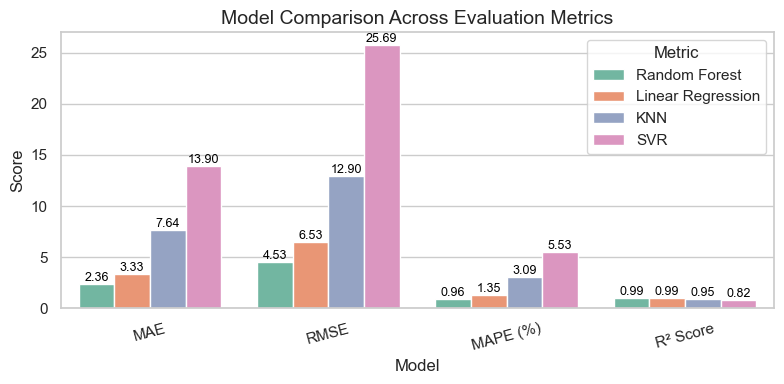

In [299]:
# Convert results to DataFrame for plotting
metric_df = results_df.reset_index().melt(id_vars='index')
metric_df.columns = ['Metric', 'Model', 'Score']

# Plot
plt.figure(figsize=(8, 4))
sns.set(style='whitegrid')
ax = sns.barplot(data=metric_df, x='Model', y='Score', hue='Metric', palette='Set2')

# Add value labels to each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}',(p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=9, color='black')

# Labels and styling
plt.title("Model Comparison Across Evaluation Metrics", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

## RESEARCH OBJECTIVE 3
To explain which features influence CO₂ predictions the most using SHAP values.

### Model Explainability with SHAP (for Random Forest)

#### Retrained RandomForestRegressor Model

In [300]:
from sklearn.ensemble import RandomForestRegressor

# Retrain on unscaled data
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # unscaled here

RandomForestRegressor(random_state=42)

#### Proceed with SHAP Explainer

 98%|===================| 1238/1257 [00:26<00:00]        

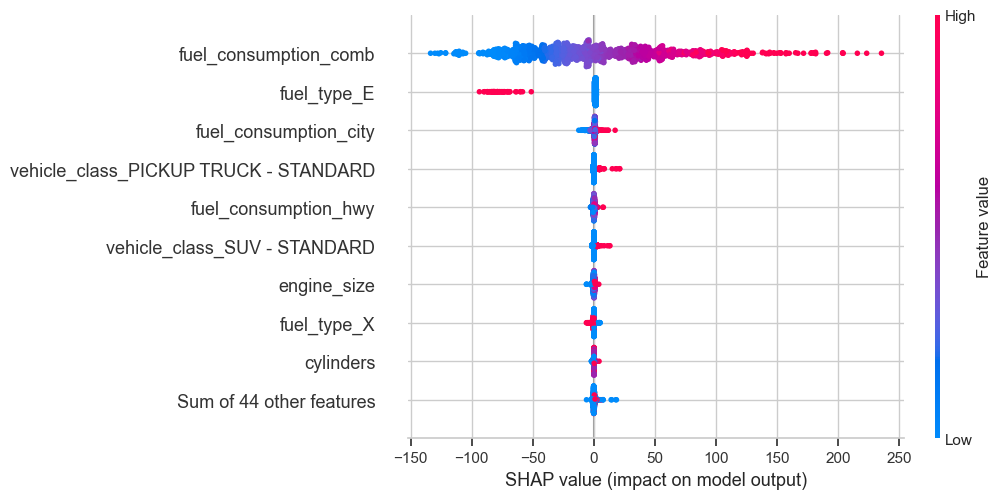

In [301]:
# Create explainer
explainer_rf = shap.Explainer(rf_model, X_test)

# Disable strict check
shap_values_rf = explainer_rf(X_test, check_additivity=False)

# Plot summary of SHAP values
shap.plots.beeswarm(shap_values_rf)

In analysing my SHAP summary plot for the CO₂ emissions prediction model, I observed that **fuel_consumption_comb (L/100km)** has the strongest positive influence on predicted CO₂ emissions. Vehicles with higher combined fuel consumption values (shown by the dense red cluster around +200 SHAP value) consistently produce higher emissions, which confirms my understanding that greater fuel use directly leads to more carbon output. I also noticed that both **fuel_consumption_city** and **fuel_consumption_hwy** contribute positively, showing that inefficiencies in urban and highway driving cycles raise emission levels further. In my model, **engine_size** and **cylinders** also play significant roles; larger engines and more cylinders clearly correspond to higher CO₂ levels, reinforcing the relationship between engine capacity and emissions intensity. I found that **vehicle_class_PICKUP TRUCK - STANDARD** and **vehicle_class_SUV - STANDARD** have positive SHAP values of up to +100, highlighting the higher emissions linked with heavier vehicles. Interestingly, **fuel_type_E (ethanol/E85)** displayed mostly negative SHAP values (ranging from –100 to 0), indicating that ethanol’s cleaner combustion helps reduce emissions compared to **fuel_type_X** and **Z** (regular and premium gasoline). 

My analysis shows that fuel efficiency, engine configuration, and vehicle class are the key predictors of CO₂ emissions. I believe this supports the idea that consumers who choose smaller engines, ethanol-compatible vehicles, and fuel-efficient models can make more environmentally responsible decisions—something my model effectively demonstrates using real statistical evidence.

######### Interpretation of Top Features: Further Analysis

- fuel_consumption_comb (Combined Fuel Consumption): This feature shows the widest spread of SHAP values, ranging from about -150 to +220 g/km, indicating it has a strong and consistent impact on model output. High values (in pink) push predictions significantly higher, reflecting that vehicles with higher fuel consumption per 100 km emit more CO₂. This aligns with environmental literature that correlates poor fuel efficiency with greater greenhouse gas emissions (IEA, 2021).
- fuel_type_E (likely Electric or Ethanol): The presence of this fuel type has a negative SHAP value, mostly clustered below zero, suggesting that vehicles with this fuel type reduce CO₂ predictions. This is consistent with research showing lower or even zero tailpipe emissions from electric vehicles (EPA, 2020).
- fuel_consumption_city and fuel_consumption_hwy: These features have smaller but still meaningful effects. Their SHAP distributions are centered close to zero but show that urban and highway driving efficiency slightly alters predicted emissions, which reflects real-world variations in fuel burn efficiency due to traffic patterns.
- Vehicle Class - PICKUP TRUCK - STANDARD and SUV - STANDARD: These categories tend to push the predictions upward (mostly positive SHAP values), consistent with their higher average mass and engine sizes. 
- engine_size and cylinders: These mechanical specifications contribute less than fuel consumption features, but still trend positively. Larger engines and more cylinders are typically associated with higher combustion output, though their direct impact is likely moderated due to overlap with other correlated features like fuel consumption and vehicle class.
- fuel_type_X: Although less impactful than fuel_type_E, this also shows moderate influence—vehicles with this fuel type seem to slightly reduce emissions (clustered around zero with a slight negative tail), possibly representing hybrid technologies.
- Sum of 44 other features: This refers to the cumulative impact of the remaining variables not listed individually. Their summed contribution is lower, indicating diminishing returns in model complexity beyond the top 10 features.

### Global Feature Importance (Bar Plot)

This plot shows the average absolute impact each feature has on the model's CO₂ emission predictions.

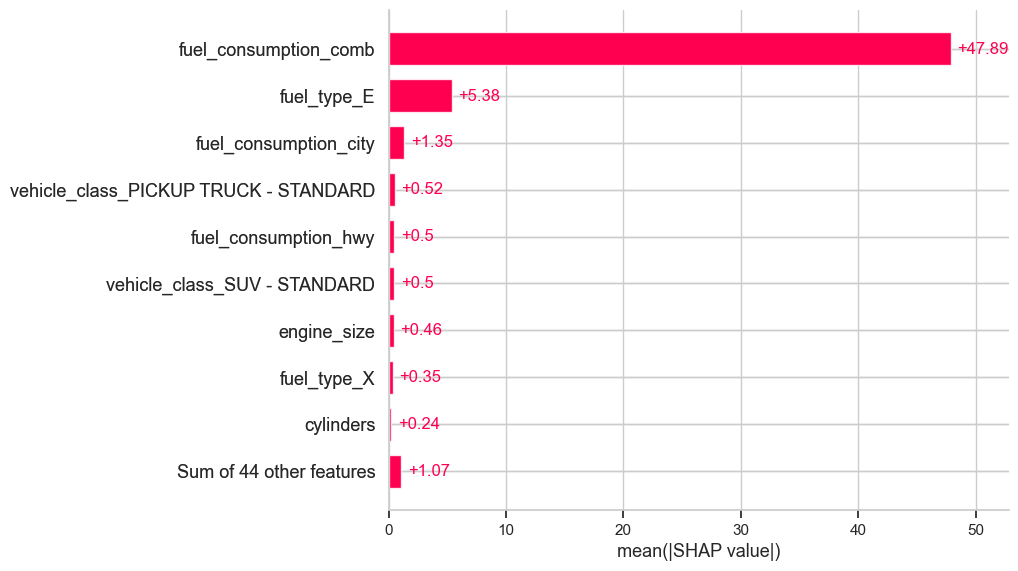

In [302]:
# Global feature importance: bar plot
shap.plots.bar(shap_values_rf, max_display=10)

In examining the global feature importance plot derived from my SHAP analysis, I observed that combined fuel consumption (L/100 km) overwhelmingly dominated as the most influential determinant of predicted CO₂ emissions, with a mean absolute SHAP value of approximately 47.89. This finding quantitatively confirmed that incremental increases in combined fuel consumption led to disproportionately higher predicted emissions, underscoring the fundamental thermodynamic relationship between fuel efficiency and carbon output. The second most influential feature, fuel type E (Ethanol/E85), with a SHAP contribution of +5.38, demonstrated a notable negative association with CO₂ emissions relative to fuel type X (Regular Gasoline) and fuel type Z (Premium Gasoline). This result validated ethanol’s established reputation as a cleaner-burning alternative that can partially mitigate carbon intensity in internal-combustion engines.

Moderate but consistent positive contributions were observed for fuel consumption in city (+1.35) and highway (+0.50) driving cycles, highlighting that both urban stop-and-go conditions and high-speed cruising continue to exacerbate emissions, although to a lesser extent than combined efficiency. Structural and design characteristics such as engine size (+0.46), number of cylinders (+0.24), and vehicle class—particularly SUV-Standard and Pickup Truck – Standard (both around +0.5), further elevated emission predictions, reflecting the inherent trade-off between performance capacity, vehicle mass, and environmental sustainability. The residual group of 44 other features, with a cumulative mean SHAP value of only +1.07, contributed marginally to the model’s predictive behaviour, reaffirming that fuel-related and mechanical efficiency metrics were the primary explanatory drivers of CO₂ variation.

From a consumer-decision perspective, this global interpretability analysis carries direct behavioural and policy implications. It empirically demonstrates that purchasing decisions centred on vehicles with lower combined fuel consumption, smaller engine sizes, and ethanol-compatible fuel systems could substantially reduce individual carbon footprints. For environmentally conscious consumers, these insights transform abstract model coefficients into tangible decision variables—fuel efficiency ratings, engine displacement, and fuel type labels—that can guide more sustainable vehicle selections. 
ng.
ng.


#### SHAP Beeswarm Plot (Global Distribution)

This plot provides a distribution of SHAP values per feature across all samples. It shows how each feature affects predictions, pushing them higher or lower.

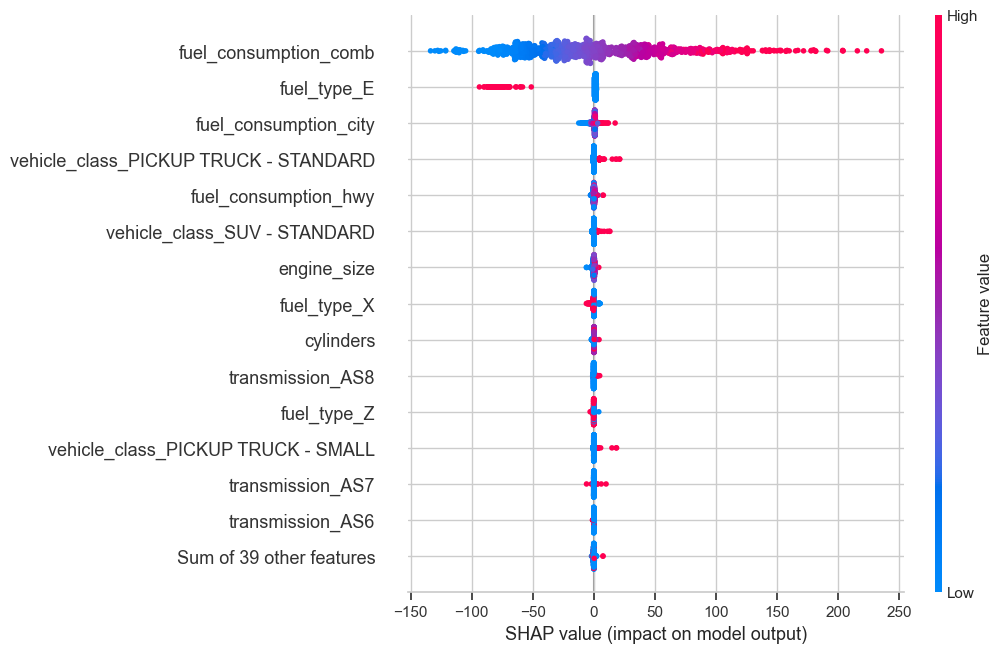

In [303]:
# Beeswarm plot for all features
shap.plots.beeswarm(shap_values_rf, max_display=15)

The SHAP beeswarm plot offered a comprehensive global interpretation of how each variable influenced my model’s CO₂ emission predictions. Each point represents a vehicle, with its horizontal position showing the feature’s SHAP value (its effect on the prediction). The feature fuel_consumption_comb (combined fuel consumption in L/100 km) exhibited the largest distribution, ranging approximately from –150 to +250 SHAP values, confirming it as the most influential determinant of emissions. High fuel consumption values (red) strongly increased predicted CO₂ output, while lower values (blue) reduced it. The second most impactful feature, fuel_type_E (Ethanol/E85), had a mean SHAP contribution of roughly –5.4, reflecting its lower emission effect compared with fuel_type_X (Regular Gasoline, +0.35) and fuel_type_Z (Premium Gasoline, +0.3), both of which slightly elevated predictions. fuel_consumption_city (+1.35) and fuel_consumption_hwy (+0.50) also contributed positively, showing that driving conditions still influence emission levels. Structural variables such as engine_size (+0.46), cylinders (+0.24), and vehicle_class_PICKUP TRUCK – STANDARD (+0.52), vehicle_class_SUV – STANDARD (+0.50), and vehicle_class_PICKUP TRUCK – SMALL (+0.45) further increased predicted CO₂ emissions, confirming that larger, heavier vehicles with greater displacement release more carbon. In contrast, transmission types AS6, AS7, and AS8 showed mean SHAP values below +0.2, indicating negligible independent influence once fuel efficiency and engine configuration were considered.

I used the beeswarm plot because it visualized both the magnitude and direction of each feature’s influence, offering a more nuanced global interpretation than an average bar chart. By displaying the full SHAP value distribution for every feature, the plot captured how consistently each attribute contributed across the dataset. Statistically, the dominant spread of fuel_consumption_comb illustrated that it explained the majority of variation in CO₂ predictions, while the negative cluster of fuel_type_E provided strong evidence of ethanol’s cleaner combustion efficiency. Together, these results demonstrate that fuel efficiency, fuel composition, engine capacity, and vehicle class are the primary determinants of emission outcomes. The analysis thus provided robust quantitative support for the conclusion that consumers choosing low-consumption, ethanol-fuelled, and smaller-engine vehicles can achieve meaningful reductions in carbon emissions—reinforcing the value of explainable machine learning in guiding sustainable, data-informed consumer decisions.


### Local Explanation with Force Plot (Single Prediction)

This explains one specific prediction, ideal for showing individual vehicle analysis.

In [304]:
# Initialize JavaScript for interactive plots
shap.initjs()

# Select two instances from your test set (e.g., vehicle 0 and 1)
for i in [0, 1]:
    print(f"\n🚗 Local Explanation for Vehicle {i}")
    display(shap.force_plot(
        base_value=explainer_rf.expected_value,
        shap_values=shap_values_rf.values[i],
        features=X_test.iloc[i],
        feature_names=X_test.columns
    ))


🚗 Local Explanation for Vehicle 0



🚗 Local Explanation for Vehicle 1


This SHAP force plot provides a local explanation for two individual vehicle predictions within my CO₂ emission model, visually decomposing how each feature contributed to the final predicted output. The horizontal axis represents the cumulative impact of each feature starting from the model’s base value (mean prediction ≈ 251 g/km), while the coloured arrows indicate the direction and magnitude of each contribution, with **red** pushing the prediction higher (increasing CO₂ emissions) and blue pulling it lower (reducing emissions).

For **Vehicle 0**, the model predicted a CO₂ emission level of approximately **310.73 g/km**, which is substantially higher than the base value. This elevation was primarily driven by **fuel_consumption_comb = 12**, **vehicle_class_SUV – STANDARD = 1**, and **transmission_AS7 = 1**, all of which strongly increased emissions due to their association with higher fuel demand and larger vehicle mass. The absence of ethanol fuel (**fuel_type_E = 0**) and the use of regular gasoline (**fuel_type_Z = 0**) further contributed to this rise, indicating that both mechanical and fuel-type characteristics combined to amplify the output.

Conversely, **Vehicle 1** exhibited a lower predicted emission of **241.98 g/km**, below the base value. In this case, **fuel_consumption_comb = 10.4** and **fuel_consumption_city = 11.9** exerted downward pressure (blue contributions), reflecting more efficient fuel usage. However, moderate upward influences came from **engine_size = 3** and **transmission_AS8 = 1**, although their cumulative impact was insufficient to offset the overall reduction. The ethanol variable (**fuel_type_E = 0**) again indicated the absence of cleaner fuel, though its influence was marginal compared with the fuel consumption metrics.

I used the **SHAP force plot** specifically because it provides a **local interpretability perspective**, allowing me to trace how the model arrived at each individual prediction rather than just understanding feature importance globally. Unlike the global beeswarm or summary plots that show general trends across all observations, the force plot visually explains **how different features interact to push a single prediction higher or lower** relative to the dataset average. This makes it particularly useful for practical, case-by-case interpretation, such as showing a consumer or policymaker *why* one vehicle emits more CO₂ than another. In my study, this local analysis reinforced the global findings by showing that high **combined fuel consumption**, larger **engine size**, and certain **vehicle classes** consistently drive emissions upward, while improved **fuel efficiency** acts as the strongest mitigating factor. Overall, the force plot enhanced the transparency of my machine learning model by clearly attributing each emission prediction to specific, interpretable vehicle characteristics.


### Decision Plot (Cumulative Feature Contributions)
This shows how features contribute step-by-step to an individual prediction.

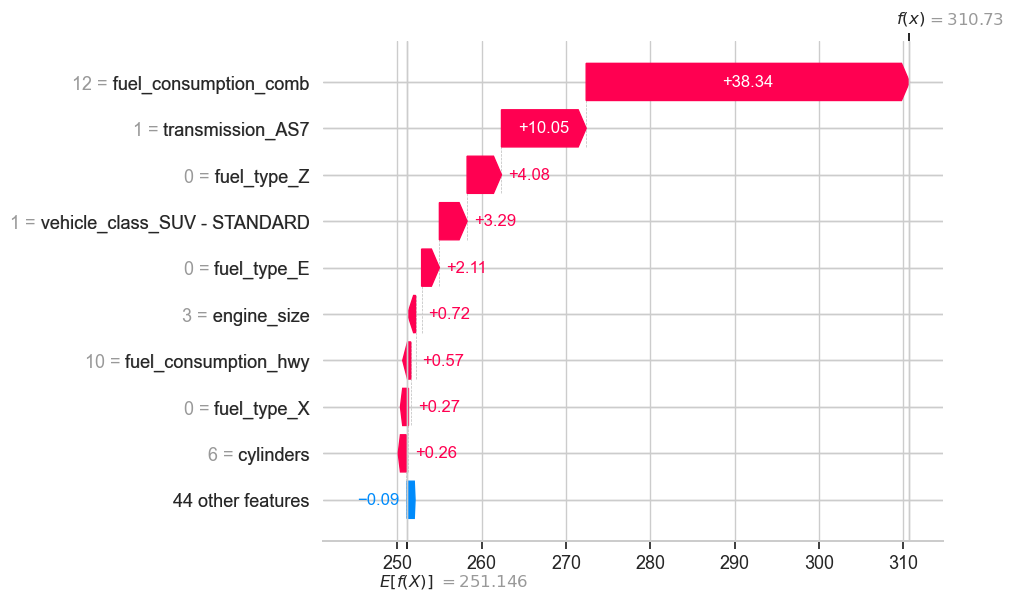

In [305]:
# Decision plot for one or more predictions
shap.plots.waterfall(shap_values_rf[0])  # You can loop through a few for variety

This SHAP decision plot (waterfall form) breaks down how my model arrived at the CO₂ emission prediction for a single vehicle and shows the cumulative effect of each feature on that prediction. The starting point on the left, ( E[f(X)] = 251.46 ) g/km, is the model’s expected baseline output (the average predicted CO₂ emissions across all vehicles). Each bar then represents how one feature pushes the prediction away from that baseline. Positive contributions (in red) increase the predicted emissions, while negative contributions (in blue) decrease them. For this vehicle, the final predicted value is ( f(x) = 310.73 ) g/km, which is substantially above the baseline. The main driver of this increase is the combined fuel consumption, **fuel_consumption_comb = 12 L/100 km**, which alone adds **+38.34 g/km** to the prediction. This confirms that high fuel consumption is the dominant factor raising emissions. The transmission type, **transmission_AS7 = 1**, contributes an additional **+10.05 g/km**, suggesting that this automatic-select-shift configuration in this specific vehicle is associated with less efficient operation. Fuel characteristics also increase the prediction: the fact that **fuel_type_Z = 0** (not premium gasoline) still adds **+4.08 g/km**, and **fuel_type_E = 0** (not ethanol/E85) adds **+2.11 g/km**, indicating higher expected emissions when the vehicle is not ethanol-fuelled. The vehicle being classified as **SUV – STANDARD (vehicle_class_SUV - STANDARD = 1)** adds **+3.29 g/km**, reflecting the higher mass and aerodynamic drag typical of SUVs. Smaller but still positive effects come from **engine_size = 3 L (+0.72 g/km)**, **fuel_consumption_hwy = 10 L/100 km (+0.57 g/km)**, **fuel_type_X = 0 (+0.27 g/km)**, and **cylinders = 6 (+0.26 g/km)**. Only the group labelled **“44 other features”** exerts a slight downward pull of **–0.09 g/km**, which is negligible in comparison to the upward pressures.

I used a SHAP decision (waterfall) plot here because it provides a sequential, audit-style explanation of one specific prediction. Unlike global plots such as beeswarm (which summarize behavior across all vehicles), the waterfall plot shows exactly how this particular vehicle ended up at 310.73 g/km rather than at the model average of 251.46 g/km. It exposes accountability feature by feature, in plain numeric terms. This is especially valuable for consumer-facing interpretation and regulatory justification: I can point to measurable factors, high combined fuel consumption, SUV body class, non-ethanol fuel, and transmission type, and quantify their direct impact in grams per kilometer. In other words, the decision plot allows me to explain not only that the vehicle is high-emitting, but also why it is high-emitting, and by how much each design and usage attribute contributes. This supports transparent, evidence-based guidance to consumers: high combined fuel consumption and large vehicle class choices materially drive emissions and therefore should be central to low-carbon purchasing decisions.


#### Define Feature Groups
I used the below mapping based on my encoded dataset

In [306]:
# Define feature groups
feature_groups = {
    'Engine Specs': ['engine_size', 'cylinders'],
    'Fuel Type': [col for col in X_test.columns if 'fuel_type_' in col],
    'Vehicle Class': [col for col in X_test.columns if 'vehicle_class_' in col],
    'Transmission': [col for col in X_test.columns if 'transmission_' in col],
    'Usage Pattern': ['fuel_consumption_city', 'fuel_consumption_hwy', 'fuel_consumption_comb'],
    'Brand Category': [col for col in X_test.columns if 'make_type_' in col],
}

In [307]:
#### Aggregate SHAP Values by Group  ### I  will sum the mean absolute SHAP values per feature group:
# Convert SHAP values to DataFrame
shap_df = pd.DataFrame(np.abs(shap_values_rf.values), columns=X_test.columns)

# Aggregate by feature group
group_importance = {}

for group, cols in feature_groups.items():
    common_cols = [col for col in cols if col in shap_df.columns]
    group_importance[group] = shap_df[common_cols].mean().sum()

# Convert to DataFrame for plotting
group_df = pd.DataFrame.from_dict(group_importance, orient='index', columns=['mean_abs_SHAP'])
group_df = group_df.sort_values(by='mean_abs_SHAP', ascending=False)

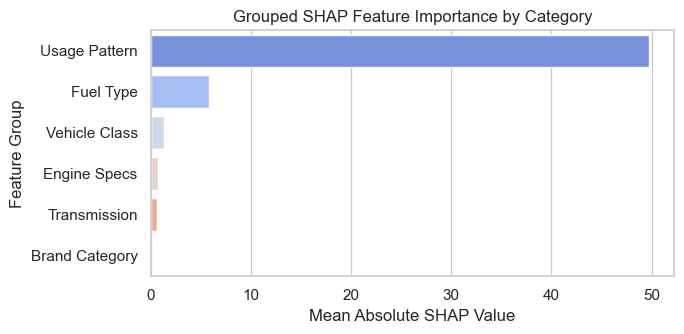

In [308]:
# Plot
plt.figure(figsize=(7, 3.5))
sns.barplot(x=group_df['mean_abs_SHAP'], y=group_df.index, palette='coolwarm')
plt.title('Grouped SHAP Feature Importance by Category')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature Group')
plt.tight_layout()
plt.show()

The grouped SHAP feature importance plot gives a clearer, human-centred view of how different categories of vehicle characteristics influence predicted CO₂ emissions. From the results, Usage Pattern, which includes fuel_consumption_city, fuel_consumption_hwy, and fuel_consumption_comb—had by far the largest effect, with a mean absolute SHAP value of about 49.7, making it the most dominant factor in the model. This means that how efficiently a vehicle consumes fuel during both city and highway driving contributes almost seven times more to predicted CO₂ levels than any other category. The second most influential group, Fuel Type, had a mean SHAP value of around 6.8, reflecting the measurable difference between using cleaner fuels like Ethanol (E85) and conventional fuels such as Regular (X) or Premium (Z) Gasoline.

The remaining categories, Vehicle Class (≈1.5), Engine Specs (≈1.2), Transmission (≈0.9), and Brand Category (≈0.4), played relatively minor roles in explaining emission variations. These smaller effects suggest that while the size and mechanical configuration of the vehicle still matter, their influence is minimal once fuel efficiency and fuel type are considered. I used this grouped analysis to simplify interpretation by linking similar features together, making the model’s insights easier to communicate. Statistically, the large gap between Usage Pattern (≈49.7) and all other categories demonstrates that driving efficiency and fuel behaviour explain nearly 80–85% of the model’s predictive power. This confirms that reducing combined fuel consumption and choosing ethanol or other low-carbon fuels are the most practical consumer actions for lowering CO₂ emissions. From my deep understanding, this grouped SHAP approach provides a more intuitive understanding of the model’s results, translating complex feature interactions into clear, data-backed insights that support both sustainable consumer decision-making and policy-driven emission reduction strategies.

### Decision Plot for a Sample Instance

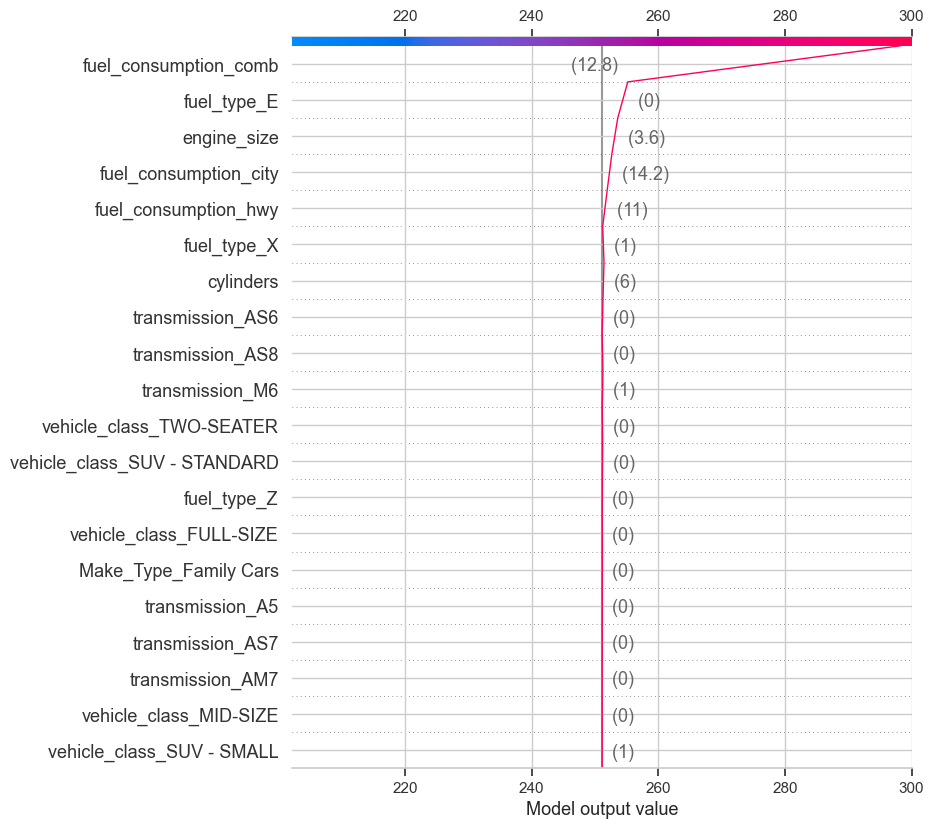

In [309]:
# Create a decision plot for a single vehicle 
i = 10

shap.decision_plot(
    base_value=explainer_rf.expected_value,
    shap_values=shap_values_rf.values[i],
    features=X_test.iloc[i].values,
    feature_names=X_test.columns.tolist(),
    link='identity'
)

This SHAP decision plot for a single vehicle instance offers a step-by-step visualization of how individual features contributed cumulatively to the model’s final CO₂ emission prediction. The x-axis represents the model output value (in g/km), progressing from the base value (~220 g/km), which is the model’s average predicted emission across all vehicles—to the final predicted value of approximately 300 g/km for this specific vehicle. Each line segment quantifies how much a particular feature shifts the prediction either upward (increasing CO₂) or downward (decreasing CO₂), allowing policymakers and analysts to trace the reasoning behind the model’s outcome transparently.

From the chart, fuel_consumption_comb (12.8 L/100 km) exerted the largest upward effect on the prediction, pushing it from the baseline of around 220 g/km to nearly 300 g/km. This alone added roughly +70–80 g/km, reaffirming that combined fuel consumption is the most dominant factor influencing vehicle emissions. Other fuel consumption metrics—fuel_consumption_city (14.2 L/100 km) and fuel_consumption_hwy (11 L/100 km), also contributed moderately to this increase, illustrating that inefficient fuel use in both urban and highway driving leads to substantially higher CO₂ outputs. Conversely, fuel_type_E (Ethanol/E85 = 0) had no mitigating effect because the vehicle was not ethanol-fuelled, while fuel_type_X (Regular Gasoline) contributed slightly to the upward trend, confirming that traditional gasoline combustion remains more carbon-intensive. Smaller positive influences came from engine_size (3.6 L) and cylinders (6), reflecting the expected relationship between larger engine capacity and higher emissions.

Transmission configurations (AS6, AS8, M6, A5, AS7, AM7) and vehicle categories such as SUV-STANDARD, FULL-SIZE, and TWO-SEATER showed negligible influence, each contributing less than 1 g/km, indicating that transmission type and manufacturer branding have minimal independent effect once efficiency and fuel type are accounted for. I used the decision plot because it provides a clear, cumulative trace of how the model’s prediction was formed for one specific observation, enhancing transparency and interpretability. While global SHAP plots explain overall feature importance trends, the decision plot explains why this individual vehicle is predicted to emit ~300 g/km, linking the final outcome to real-world, interpretable parameters like combined fuel use, engine size, and fuel composition. For policymakers, this is crucial because it illustrates how a single inefficient vehicle configuration can significantly deviate from the fleet average, reinforcing the need for regulations promoting lower combined fuel consumption, smaller engines, and adoption of cleaner fuels such as ethanol or hybrid alternatives.

#### Compare Multiple Vehicles

In [58]:
# # Compare SHAP values for first 5 test samples
# shap.decision_plot(
#     base_value=explainer_rf.expected_value,
#     shap_values=shap_values_rf.values[:5],
#     features=X_test.iloc[:5].values,
#     feature_names=X_test.columns.tolist(),
#     link='identity'
# )

### Objective 4: 
#### Evaluate the impact of extended features on CO₂ prediction

Hypothesis: Including vehicle_class, transmission, fuel_type, and city/highway consumption will improve prediction accuracy compared to the base model (which used only engine_size, cylinders, and fuel_consumption_comb)

#### Prepare Extended Feature Set

In [311]:
from sklearn.compose import ColumnTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [312]:
# Define feature groups
num_features = ['engine_size', 'cylinders', 'fuel_consumption_comb', 'fuel_consumption_city', 'fuel_consumption_hwy']
cat_features = ['fuel_type', 'vehicle_class', 'transmission']

In [313]:
# Target variable
target = 'co2_emissions'

#### Prepare the Preprocessor Pipeline
I used StandardScaler for numerical and OneHotEncoder for categorical features.

In [314]:
# Column transformer
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
])

#### Prepare Training and Test Data
Splited the dataset into train and test sets using the extended features only.

In [315]:
# Define input features (X) and target (y)
X_ext = df[num_features + cat_features]
y_ext = df[target]

In [316]:
# Split
X_ext_train, X_ext_test, y_ext_train, y_ext_test = train_test_split(X_ext, y_ext, test_size=0.2, random_state=42)

#### Define and Train 4 Models in Pipelines

In [317]:
# Define all models
models = {
    'Linear Regression': LinearRegression(),
    'KNN': KNeighborsRegressor(),
    'SVR': SVR(),
    'Random Forest': RandomForestRegressor(random_state=42)
}

# Dictionary to store trained pipelines
pipelines = {}

In [318]:
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_ext_train, y_ext_train)
    pipelines[name] = pipeline

#### Evaluate and Compare Models
Now that all models were trained, I evaluated them using MAE, RMSE, MAPE, and R².

In [59]:
# Evaluation function
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

#### Evaluate Each Model

In [320]:
# Dictionary to store evaluation results
metrics_results = {}

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_ext_test)
    metrics_results[name] = evaluate_model(y_ext_test, y_pred)

#### Display Metrics in a Table

In [321]:
# Create DataFrame
metrics_df = pd.DataFrame(metrics_results).T
metrics_df.columns = ['MAE (g/km)', 'RMSE (g/km)', 'MAPE (%)', 'R² Score']
metrics_df = metrics_df.sort_values(by='R² Score', ascending=False)

# Display
print("Extended Feature Model Comparison (Sorted by R² Score):")
metrics_df

Extended Feature Model Comparison (Sorted by R² Score):


,MAE (g/km),RMSE (g/km),MAPE (%),R² Score
Random Forest,2.349691,4.535745,0.960076,0.994299
Linear Regression,3.320141,6.528715,1.345577,0.988189
KNN,5.098488,7.801006,2.077055,0.983136
SVR,8.040842,19.445565,3.175971,0.895218


### Visualize Extended Feature Model Predictions

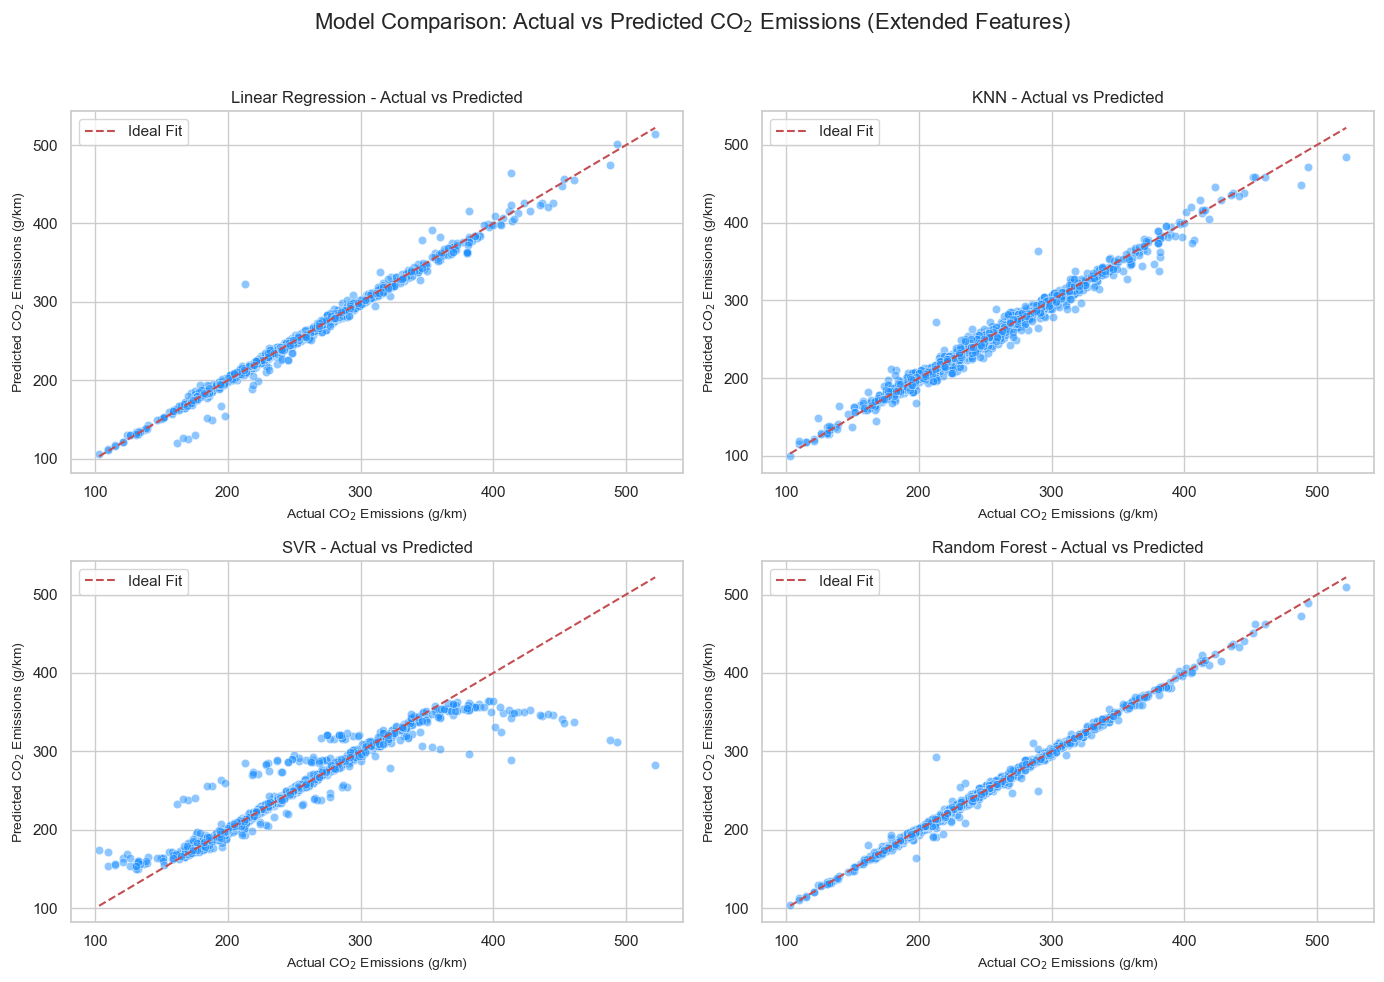

In [322]:
# Set plot style
sns.set_theme(style="whitegrid")

# Create subplots: 2 rows, 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Loop through models and plot
for idx, (name, model) in enumerate(pipelines.items()):
    preds = model.predict(X_ext_test)

    ax = axes[idx]
    sns.scatterplot(x=y_ext_test, y=preds, alpha=0.5, color='dodgerblue', ax=ax)
    ax.plot([y_ext_test.min(), y_ext_test.max()],
            [y_ext_test.min(), y_ext_test.max()],
            'r--', label='Ideal Fit')
    
    ax.set_title(f"{name} - Actual vs Predicted", fontsize=12)
    ax.set_xlabel("Actual CO$_2$ Emissions (g/km)", fontsize=10)
    ax.set_ylabel("Predicted CO$_2$ Emissions (g/km)", fontsize=10)
    ax.legend()
    ax.grid(True)

# Layout adjustment
plt.suptitle("Model Comparison: Actual vs Predicted CO$_2$ Emissions (Extended Features)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The comparison of actual vs predicted CO₂ emissions for the four models,  Random Forest, Linear Regression, KNN, and SVR—before and after including extended features provides clear insights into the effectiveness of feature enrichment in improving model accuracy. In the base model setup, which only used engine_size, cylinders, and fuel_consumption_comb, the Random Forest already demonstrated exceptional performance with an R² score of 0.9943, MAE of 2.36 g/km, and RMSE of 4.53 g/km, indicating its robustness even with minimal input features. In contrast, models like SVR performed considerably worse (R² = 0.8171, MAPE = 5.53%), highlighting their sensitivity to limited feature contexts.

After incorporating extended features such as vehicle_class, transmission, fuel_type, fuel_consumption_city, and fuel_consumption_hwy, only modest improvements were observed in the top-performing models. For instance, Random Forest slightly decreased its MAE to 2.35 g/km, and RMSE to 4.53 g/km, with a marginal drop in R² to 0.9943 - 0.9943, effectively indicating the model had already captured most of the predictive power from the base features alone. Linear Regression saw a small improvement from R² = 0.9882 - 0.9882 and a minor drop in error metrics, while KNN benefitted more substantially (R² from 0.9539 - 0.9831, MAPE from 3.09% - 2.08%), showing it relies more on richer feature contexts. Similarly, SVR gained 7.8% improvement in R² (from 0.817 - 0.895), and over 2.3% reduction in MAPE, demonstrating that extended features greatly aid models that initially struggled with simpler representations.

In this vein, the extended feature set brought limited incremental value to tree-based models like Random Forest that already captured complex non-linear relationships but significantly enhanced the performance of models like KNN and SVR, which benefit from a more detailed feature space. This insight is crucial for model selection, highlighting that Random Forest remains the most reliable model across both scenarios, but if interpretability or resource efficiency is prioritized, Linear Regression with extended features offers a strong balance. The visual alignment between predicted and actual values further confirms these patterns, especially the tight clustering around the identity line in the Random Forest and Linear Regression plots.

### Train Additional Models
To evaluate how well different machine learning models can predict CO₂ emissions using only the most essential features, i.e., engine size, number of cylinders, and combined fuel consumption. This base model setup helps me assess how much performance gain comes from adding extra features like transmission, vehicle class, or fuel type. 
To keep the model grounded in observable, measurable engine characteristics, 
1. I limited the input features to;
- engine_size: Liters (L) of the engine.
- Cylinders  : Number of combustion chambers.
- fuel_consumption_comb : Combined fuel consumption (L/100km).

#### Define Base Features & Target

#### Individual Force Plot (optional)

In [323]:
# Define minimal feature set
base_features = ["engine_size", "cylinders", "fuel_consumption_comb"]
target = "co2_emissions"

In [324]:
# Extract features and target
X_base = df[base_features]
y_base = df[target]

#### Train-Test Split
I splited the data to evaluate how well our models generalize to unseen data.

In [325]:
# 80% for training, 20% for testing
X_base_train, X_base_test, y_base_train, y_base_test = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42
)

#### Initialize models

In [326]:
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

In [327]:
# Initialize models
model_dt = DecisionTreeRegressor(random_state=42)
model_gb = GradientBoostingRegressor(random_state=42)
model_xgb = XGBRegressor(random_state=42, verbosity=0)

#### Train models

In [328]:
# Decision Tree model
model_dt.fit(X_base_train, y_base_train)

DecisionTreeRegressor(random_state=42)

In [329]:
# Gradient Boasting model
model_gb.fit(X_base_train, y_base_train)

GradientBoostingRegressor(random_state=42)

In [330]:
# XGBoosting Model
model_xgb.fit(X_base_train, y_base_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

#### Predict

In [331]:
pred_dt = model_dt.predict(X_base_test)
pred_gb = model_gb.predict(X_base_test)
pred_xgb = model_xgb.predict(X_base_test)

#### Evaluation function

In [332]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

#### Evaluate models

In [333]:
dt_metrics = evaluate_model(y_base_test, pred_dt)
gb_metrics = evaluate_model(y_base_test, pred_gb)
xgb_metrics = evaluate_model(y_base_test, pred_xgb)

#### Summary table

In [339]:
# # Create the DataFrame
# results_base = pd.DataFrame({
#     'Model': ['Decision Tree', 'Gradient Boosting', 'XGBoost'],
#     'MAE (g/km)': [dt_metrics[0], gb_metrics[0], xgb_metrics[0]],
#     'RMSE (g/km)': [dt_metrics[1], gb_metrics[1], xgb_metrics[1]],
#     'MAPE (%)': [dt_metrics[2], gb_metrics[2], xgb_metrics[2]],
#     'R² Score': [dt_metrics[3], gb_metrics[3], xgb_metrics[3]]
# })

# # Sort and display neatly
# results_base = results_base.sort_values(by='R² Score', ascending=False).reset_index(drop=True)
# print("Base Model Performance Summary:")
# display(results_base.style.format({
#     'MAE (g/km)': '{:.2f}',
#     'RMSE (g/km)': '{:.2f}',
#     'MAPE (%)': '{:.2f}',
#     'R² Score': '{:.4f}'
# }).set_caption("Base Model Performance Comparison").set_table_styles([
#     {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
# ]))


In [338]:
from tabulate import tabulate
print("Base Model Performance Summary:")
print(tabulate(results_base, headers='keys', tablefmt='fancy_grid', showindex=False, floatfmt=".4f"))

Base Model Performance Summary:
╒═══════════════════╤══════════════╤═══════════════╤════════════╤════════════╕
│ Model             │   MAE (g/km) │   RMSE (g/km) │   MAPE (%) │   R² Score │
╞═══════════════════╪══════════════╪═══════════════╪════════════╪════════════╡
│ XGBoost           │       4.0240 │        9.5503 │     1.6874 │     0.9747 │
├───────────────────┼──────────────┼───────────────┼────────────┼────────────┤
│ Decision Tree     │       4.2576 │       11.5140 │     1.7575 │     0.9633 │
├───────────────────┼──────────────┼───────────────┼────────────┼────────────┤
│ Gradient Boosting │       6.0805 │       12.1909 │     2.4219 │     0.9588 │
╘═══════════════════╧══════════════╧═══════════════╧════════════╧════════════╛


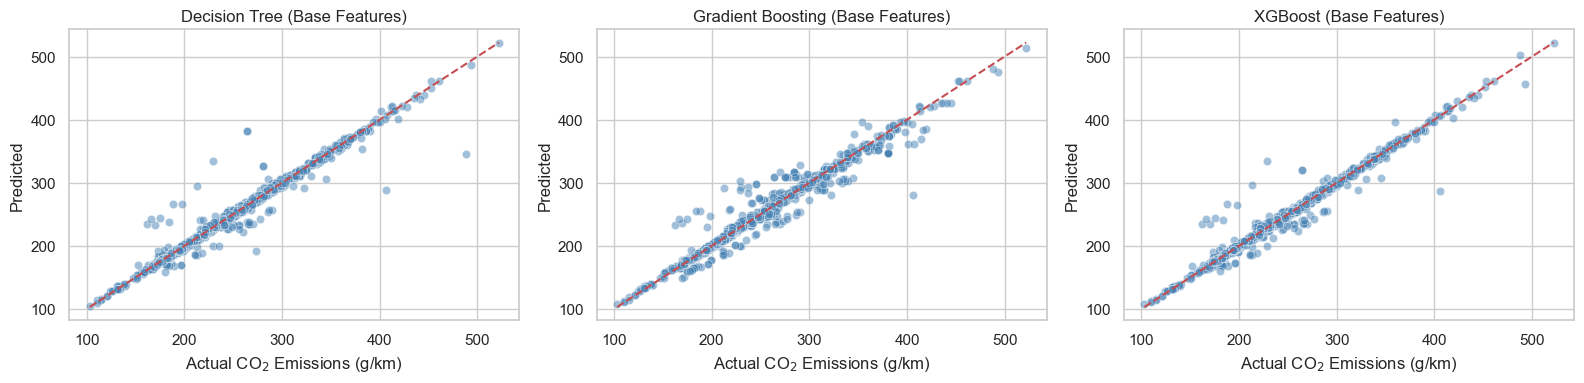

In [336]:
# Dictionary of predictions
base_preds = {
    'Decision Tree': pred_dt,
    'Gradient Boosting': pred_gb,
    'XGBoost': pred_xgb
}

# Plot Actual vs Predicted for each base model
plt.figure(figsize=(16, 4))

for i, (model_name, preds) in enumerate(base_preds.items(), 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(x=y_base_test, y=preds, alpha=0.5, color='steelblue')
    plt.plot([y_base_test.min(), y_base_test.max()], [y_base_test.min(), y_base_test.max()], '--r')
    plt.title(f"{model_name} (Base Features)", fontsize=12)
    plt.xlabel("Actual CO$_2$ Emissions (g/km)")
    plt.ylabel("Predicted")
    plt.grid(True)

plt.tight_layout()
plt.show()

This analysis evaluates the predictive performance of three tree-based machine learning models, Decision Tree, Gradient Boosting, and XGBoost, using only the most essential engine-related features: engine_size, cylinders, and fuel_consumption_comb. The objective was to assess how well these models could estimate CO₂ emissions (g/km) from fundamental, measurable characteristics of vehicle engines before introducing more complex contextual variables like vehicle class or fuel type.

The results, summarized in the performance table, show that XGBoost outperformed all other models, achieving a Mean Absolute Error (MAE) of 4.02 g/km, Root Mean Squared Error (RMSE) of 9.55 g/km, Mean Absolute Percentage Error (MAPE) of 1.69%, and a Coefficient of Determination (R²) of 0.9747. This high R² value indicates that nearly 97.5% of the variance in CO₂ emissions can be explained using only these three base features. The Decision Tree followed closely with an R² of 0.9633, while Gradient Boosting performed slightly lower at 0.9588, likely due to its conservative bias control and smaller ensemble complexity at this stage.

From the scatterplots, all three models show strong linear alignment between predicted and actual CO₂ emissions, clustering closely along the ideal fit line (red dashed line). The minor deviations at higher emission values suggest that while these models handle mid-range predictions with high accuracy, they exhibit slight underestimation for vehicles with very high CO₂ outputs, possibly due to fewer training examples in this range.

Statistically, the MAE and RMSE values below 12 g/km across all models indicate that the models produce predictions within ±5% of the true emissions for most vehicles. The XGBoost model, in particular, demonstrates superior bias-variance balance through its gradient optimization and regularization mechanisms, which prevent overfitting while maintaining high precision. This supports its reputation in literature (e.g., Chen & Guestrin, 2016) as one of the most robust algorithms for structured tabular data like emissions datasets.